# Controlled k-sensitivity analysis for KDB, dKDB, and sKDB

This is a diagnostic companion to the existing comparative-study notebooks. It does **not** modify or execute the existing PAPER_FIDELITY experiment and it never writes to that experiment's result or processed-data caches.

The experiment has four explicitly separated outputs:

- **KDB** at configured `k = 0, …, 5`.
- **dKDB** at the same values and on exactly the same outer splits.
- **sKDB-fixed-n**, a diagnostic model whose MI-ranked feature prefix is selected once from the outer-training fold by native sKDB and then frozen across every `k`.
- **sKDB-native**, the paper-faithful joint selection of feature-prefix length and dependency order using training data only.

## Deliberate dKDB backoff correction

The inherited implementation learns discriminative factor weights for the deepest contexts observed during training. Previously, when a test row backed off to a lower-order conditional table, that lower-order table usually had no discriminative weight and the feature contribution was silently omitted. This notebook applies the smallest behavior correction: a backed-off conditional without a learned discriminative weight is retained with neutral weight `1.0`. Full-context predictions and the optimizer are unchanged. Every use of this correction is counted.

The existing source notebooks, their outputs, and their caches remain untouched.


## 1. Imports and experiment configuration

`SMOKE` is intentionally cheap and is the default. Set `EXPERIMENT_MODE = "FULL"` only when ready for the complete 2×2 experiment. Dataset, learner, and k selections can be narrowed without changing the cache identity of unrelated configurations.


In [1]:
from __future__ import annotations

import bz2
import gc
import gzip
import io
import json
import lzma
import math
import os
import pickle
import platform
import subprocess
import sys
import tarfile
import urllib.request
import warnings
import zipfile
from collections import Counter
from collections.abc import Callable, Iterator, Mapping, Sequence
from contextlib import contextmanager
from dataclasses import asdict, dataclass
from hashlib import sha256
from math import log2
from pathlib import Path
from time import perf_counter, sleep

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display
from scipy.io import arff
from scipy.stats import t
from sklearn.datasets import fetch_covtype, fetch_openml, load_svmlight_file
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ---------------------------- EDIT THESE ----------------------------
EXPERIMENT_MODE = "FULL"       # SMOKE | FULL
RANDOM_SEED = 5
K_VALUES = (0, 1, 2, 3, 4, 5)
SELECTED_DATASETS = None         # None -> mode default; otherwise tuple of dataset names
SELECTED_LEARNERS = ("KDB", "dKDB", "sKDB-fixed-n", "sKDB-native")
RUN_EXPERIMENT = True
RESUME_COMPLETED_RUNS = True
FAIL_FAST = False

D = 1
OPTIMIZER = "adagrad"
LEARNING_RATE = 0.01
ADAGRAD_EPSILON = 1e-9

MODE_CONFIGS_CONTROLLED = {
    "SMOKE": {
        "datasets": ("Skin Segmentation", "cod-rna"),
        "folds": 2,
        "repeats": 1,
        "row_limits": {"Skin Segmentation": 800, "cod-rna": 800},
        "evaluation_scope": "controlled k-sensitivity smoke test",
    },
    "FULL": {
        "datasets": (
            "CensusIncome", "Covertype", "Localization", "MiniBooNE",
            "PokerHand", "Skin Segmentation", "TwitterAbsoluteSigma", "cod-rna",
        ),
        "folds": 2,
        "repeats": 2,
        "row_limits": {},
        "evaluation_scope": "controlled k-sensitivity full 2 rounds x 2 folds",
    },
}

if EXPERIMENT_MODE not in MODE_CONFIGS_CONTROLLED:
    raise ValueError(f"Unknown EXPERIMENT_MODE={EXPERIMENT_MODE!r}")
if tuple(sorted(set(K_VALUES))) != tuple(K_VALUES) or any(int(k) != k or k < 0 for k in K_VALUES):
    raise ValueError("K_VALUES must be sorted, unique, non-negative integers")
if not set(SELECTED_LEARNERS).issubset({"KDB", "dKDB", "sKDB-fixed-n", "sKDB-native"}):
    raise ValueError("Unknown learner selection")

REPOSITORY_ROOT = Path.cwd().resolve()
REFERENCE_NOTEBOOK = REPOSITORY_ROOT / "KDB Family - Multi-Dataset Comparative Benchmark - Runtime Optimized.ipynb"
SHARED_RAW_CACHE = REPOSITORY_ROOT / "KDB family runtime-optimized cache" / "raw-datasets"
CONTROLLED_CACHE_ROOT = REPOSITORY_ROOT / "controlled k sensitivity cache"
CONTROLLED_RAW_CACHE = CONTROLLED_CACHE_ROOT / "raw-datasets"
PROCESSED_DATA_CACHE = CONTROLLED_CACHE_ROOT / "processed-datasets"
RESULT_CACHE_ROOT = CONTROLLED_CACHE_ROOT / "results"

# Runtime constants required by the unchanged reference implementation.
K = max(K_VALUES)
KMAX = max(K_VALUES)
SENSITIVITY_K_VALUES = tuple(K_VALUES)
MDL_N_JOBS = max(1, min(4, os.cpu_count() or 1))
STRUCTURE_BATCH_MAX_ROWS = 8_192
STRUCTURE_BATCH_TARGET_CELLS = 3_000_000
PARAMETER_BATCH_ROWS = 8_192
SELECTION_BATCH_ROWS = 4_096
DISCRIMINATIVE_BATCH_ROWS = 4_096
PREDICTION_BATCH_ROWS = 16_384
DOWNLOAD_TIMEOUT_SECONDS = 90
DOWNLOAD_RETRIES = 6
DOWNLOAD_CHUNK_BYTES = 8 * 1024 * 1024
SOURCE_CHUNK_ROWS = 8192
DATASET_EXTENSION_VERSION = "fewpla-datasets-v1"
REQUIRE_PAPER_SHAPE = False
DATASET_SOURCE_OVERRIDES = {}
ENABLE_PROCESSED_DATA_CACHE = True
ENABLE_RESULT_CACHE = True
CACHE_SCHEMA_VERSION = 1
PROCESSED_CACHE_SCHEMA = 2
CONFIGURATION_ID = "bootstrap"
DIRECT_SOURCE_SHA256 = "bootstrap"
OPTIMIZATION_LAYER_SHA256 = "loaded-from-reference"
TWITTER_CLASSIFICATION_URL = (
    "https://lig-aptikal.imag.fr/all-data/data/buzz/classification/Twitter/"
    "Absolute_labeling/Twitter-Absolute-Sigma-500.data"
)

# Bootstrap objects expected while the selected reference definition cells execute.
REQUESTED_DATASETS = (
    "PokerHand", "Diabetes", "Localization", "TwitterAbsoluteSigma", "CensusIncome",
)
ALL_CORE_DATASETS = ("Skin Segmentation", "MiniBooNE", "cod-rna", "Covertype") + REQUESTED_DATASETS
MODE_CONFIGS = {
    "SMOKE": {"datasets": (), "folds": 2, "repeats": 1, "row_limits": {}, "scaling_rows": (), "stress_test_rows": None, "use_predefined_holdout": False, "max_minutes": None, "evaluation_scope": "bootstrap"},
    "CORE_PRACTICAL": {"datasets": (), "folds": 2, "repeats": 1, "row_limits": {}, "scaling_rows": (), "stress_test_rows": None, "use_predefined_holdout": False, "max_minutes": None, "evaluation_scope": "bootstrap"},
    "CORE_FULL": {"datasets": (), "folds": 2, "repeats": 1, "row_limits": {}, "scaling_rows": (), "stress_test_rows": None, "use_predefined_holdout": False, "max_minutes": None, "evaluation_scope": "bootstrap"},
    "STRESS_PRACTICAL": {"datasets": (), "folds": 1, "repeats": 1, "row_limits": {}, "scaling_rows": (), "stress_test_rows": None, "use_predefined_holdout": True, "max_minutes": None, "evaluation_scope": "bootstrap"},
    "STRESS_FULL": {"datasets": (), "folds": 1, "repeats": 1, "row_limits": {}, "scaling_rows": (), "stress_test_rows": None, "use_predefined_holdout": True, "max_minutes": None, "evaluation_scope": "bootstrap"},
    "PAPER_FIDELITY": {"datasets": (), "folds": 2, "repeats": 2, "row_limits": {}, "scaling_rows": (), "stress_test_rows": None, "use_predefined_holdout": False, "max_minutes": None, "evaluation_scope": "bootstrap"},
}
ACTIVE_MODE = MODE_CONFIGS["PAPER_FIDELITY"]
DATA_CACHE_DIR = SHARED_RAW_CACHE


## 2. Load the frozen implementation by verified source fingerprint

The repository has no importable `.py` source modules; the maintained implementation lives in the runtime-optimized notebook. The following cell loads only definition cells—never its run cells—and refuses to proceed if those definitions have changed since this diagnostic notebook was created. This avoids executing or modifying PAPER_FIDELITY while preserving the exact fitters, preprocessing, loaders, and split logic.


In [2]:
REFERENCE_CODE_SHA256_EXPECTED = "490f7a07ca216db39a232ae7cb46fc7bbf4ecbb811de1ae7264d092ed0890d6c"
REFERENCE_SOURCE_MARKERS = ['def _entropy(counts: np.ndarray)', 'class PassRecord:', 'class KDBClassifier:', 'class NaiveBayesClassifier(KDBClassifier):', 'class _WeightedBNMixin:', 'def _categorical_matrix(X: Sequence)', 'class _RuntimeOptimizedCountingMixin:', 'DATASET_REGISTRY = {', 'PAPER_DATASET_SHAPES = {', 'PROCESSED_CACHE_SCHEMA = 2', 'class EvaluationConfig:']

if not REFERENCE_NOTEBOOK.is_file():
    raise FileNotFoundError(f"Reference notebook not found: {REFERENCE_NOTEBOOK}")

reference_document = json.loads(REFERENCE_NOTEBOOK.read_text(encoding="utf-8"))
reference_code_cells = [cell for cell in reference_document["cells"] if cell.get("cell_type") == "code"]

def _cell_source(cell):
    value = cell.get("source", "")
    return "".join(value) if isinstance(value, list) else str(value)

reference_sources = []
for marker in REFERENCE_SOURCE_MARKERS:
    matches = [_cell_source(cell) for cell in reference_code_cells if marker in _cell_source(cell)]
    if len(matches) != 1:
        raise RuntimeError(f"Expected one reference cell containing {marker!r}; found {len(matches)}")
    reference_sources.append(matches[0])

REFERENCE_CODE_SHA256 = sha256(
    "\n\n# --- selected reference cell boundary ---\n\n".join(reference_sources).encode("utf-8")
).hexdigest()
if REFERENCE_CODE_SHA256 != REFERENCE_CODE_SHA256_EXPECTED:
    raise RuntimeError(
        "The reference implementation changed. Review the changes and regenerate this notebook "
        f"before running. Expected {REFERENCE_CODE_SHA256_EXPECTED}, got {REFERENCE_CODE_SHA256}."
    )

for marker, source in zip(REFERENCE_SOURCE_MARKERS, reference_sources):
    if marker == "PAPER_DATASET_SHAPES = {":
        # The saved reference notebook relied on stale live-kernel registry
        # entries for these two source-required datasets. Supply only the
        # metadata needed for its definition cell to execute from a fresh kernel.
        DATASET_REGISTRY.setdefault("Waveform", {
            "source": "Original FewPLa Waveform file required",
            "url": None,
            "group": "core",
            "note": "UCI shape differs from the paper; an original experiment file is required.",
        })
        DATASET_REGISTRY.setdefault("WearableComputing", {
            "source": "Original FewPLa WearableComputing file required",
            "url": None,
            "group": "core",
            "note": "The full original PUC-Rio experiment file is required.",
        })
    exec(compile(source, f"{REFERENCE_NOTEBOOK.name}::<{marker}>", "exec"), globals())

REFERENCE_NOTEBOOK_FILE_SHA256 = sha256(REFERENCE_NOTEBOOK.read_bytes()).hexdigest()
try:
    REPOSITORY_COMMIT_ACTUAL = subprocess.check_output(
        ["git", "-c", f"safe.directory={REPOSITORY_ROOT}", "-C", str(REPOSITORY_ROOT), "rev-parse", "HEAD"],
        text=True,
    ).strip()
except Exception as exc:
    REPOSITORY_COMMIT_ACTUAL = f"unavailable: {type(exc).__name__}: {exc}"

print("Verified reference implementation source:", REFERENCE_CODE_SHA256)
print("Reference notebook file SHA256:", REFERENCE_NOTEBOOK_FILE_SHA256)
print("Actual repository commit:", REPOSITORY_COMMIT_ACTUAL)


,dataset,source_status,paper_rows_features_classes,source,note
0,PokerHand,automatic source configured; download/schema c...,"(164860, 10, 10)","UCI 158, complete training + test partitions","UCI has 1,025,010 rows; paper Table 1 says 164..."
1,Diabetes,original file required,"(101766, 46, 2)","FewPLa binary Diabetes, original experiment fi...",Raw UCI readmitted has 3 classes; the paper do...
2,Localization,automatic source configured; download/schema c...,"(164860, 4, 11)",UCI 196 ConfLongDemo_JSI: tag identifier and x...,Four-feature reconstruction: omit sequence ide...
3,TwitterAbsoluteSigma,automatic source configured; download/schema c...,"(140607, 77, 2)",UCI 248 donor archive: Twitter Absolute Sigma 500,"Use published classification labels, never the..."
4,CensusIncome,automatic source configured; download/schema c...,"(299285, 41, 2)","UCI 117 Census-Income (KDD), both partitions, ...","UCI instructs excluding instance weight, givin..."


Verified reference implementation source: 490f7a07ca216db39a232ae7cb46fc7bbf4ecbb811de1ae7264d092ed0890d6c
Reference notebook file SHA256: 62e1a4fe2c89f019fe82ac595bd08410153cbd462b1d39c49774532249d1e3a5
Actual repository commit: 67c54be3d358353dd4ddde4a119aff458f409dbc


## 3. Controlled namespace, provenance, and source policy

Raw downloads already used by the project are reused read-only. Processed data, results, attempts, and exported tables are written only beneath `controlled k sensitivity cache/`. Missing shared raw inputs cause a clear failure rather than modifying PAPER_FIDELITY's cache.

The current repository documents three source variants: PokerHand row count, TwitterAbsoluteSigma row count, and CensusIncome feature count differ from the paper table. These flags are retained in every result; dimensional agreement is never represented as proof of paper-file identity.


In [3]:
ACTIVE_MODE = dict(MODE_CONFIGS_CONTROLLED[EXPERIMENT_MODE])
ACTIVE_DATASETS = tuple(SELECTED_DATASETS or ACTIVE_MODE["datasets"])
unknown_datasets = set(ACTIVE_DATASETS) - set(DATASET_REGISTRY)
if unknown_datasets:
    raise KeyError(f"Unknown datasets: {sorted(unknown_datasets)}")

DATA_CACHE_DIR = SHARED_RAW_CACHE
PROCESSED_DATA_CACHE = CONTROLLED_CACHE_ROOT / "processed-datasets"
RESULT_CACHE_ROOT = CONTROLLED_CACHE_ROOT / "results"
DIRECT_SOURCE_SHA256 = REFERENCE_CODE_SHA256

CONFIG_PAYLOAD = {
    "schema": CACHE_SCHEMA_VERSION,
    "experiment": "controlled-k-sensitivity",
    "mode": EXPERIMENT_MODE,
    "mode_config": ACTIVE_MODE,
    "active_datasets": ACTIVE_DATASETS,
    "selected_learners": SELECTED_LEARNERS,
    "k_values": K_VALUES,
    "seed": RANDOM_SEED,
    "reference_code_sha256": REFERENCE_CODE_SHA256,
    "repository_commit": REPOSITORY_COMMIT_ACTUAL,
    "d": D,
    "optimizer": OPTIMIZER,
    "learning_rate": LEARNING_RATE,
    "adagrad_epsilon": ADAGRAD_EPSILON,
    "dkdb_backoff_policy": "lower-order generative conditional with neutral weight 1.0 when no discriminative weight exists",
    "source_overrides": DATASET_SOURCE_OVERRIDES,
    "strict_paper_shape": REQUIRE_PAPER_SHAPE,
}
CONFIGURATION_ID = sha256(
    json.dumps(CONFIG_PAYLOAD, sort_keys=True, default=str).encode("utf-8")
).hexdigest()[:20]
EXPERIMENT_DIRECTORY = RESULT_CACHE_ROOT / CONFIGURATION_ID

EXPECTED_SHARED_RAW_PATHS = {
    "Skin Segmentation": SHARED_RAW_CACHE / "openml" / "openml.org" / "api" / "v1" / "json" / "data" / "1502.gz",
    "MiniBooNE": SHARED_RAW_CACHE / "openml" / "openml.org" / "api" / "v1" / "json" / "data" / "41150.gz",
    "cod-rna": SHARED_RAW_CACHE / "cod-rna.train.libsvm",
    "Covertype": SHARED_RAW_CACHE / "covertype" / "samples_py3",
    "PokerHand": SHARED_RAW_CACHE / "uci-158.zip",
    "Localization": SHARED_RAW_CACHE / "uci-196.zip",
    "TwitterAbsoluteSigma": SHARED_RAW_CACHE / "Twitter-Absolute-Sigma-500.data",
    "CensusIncome": SHARED_RAW_CACHE / "uci-117.zip",
}
missing_raw = [str(EXPECTED_SHARED_RAW_PATHS[name]) for name in ACTIVE_DATASETS
               if name in EXPECTED_SHARED_RAW_PATHS and not EXPECTED_SHARED_RAW_PATHS[name].exists()]
if missing_raw:
    raise FileNotFoundError(
        "Required shared raw inputs are missing. This notebook will not write into the existing cache:\n"
        + "\n".join(missing_raw)
    )

_reference_download = _download
def _download(url: str, filename: str) -> Path:
    existing = SHARED_RAW_CACHE / filename
    if existing.exists() and existing.stat().st_size > 0:
        return existing
    raise FileNotFoundError(
        f"Raw input {filename!r} is not present in the shared read-only cache. "
        "Populate it separately or explicitly configure a new raw source cache."
    )

print(f"MODE={EXPERIMENT_MODE} | configuration_id={CONFIGURATION_ID}")
print("Datasets:", ACTIVE_DATASETS)
print("Controlled cache:", CONTROLLED_CACHE_ROOT.resolve())
display(pd.DataFrame([CONFIG_PAYLOAD]))


MODE=FULL | configuration_id=ac255f2a40133425e871
Datasets: ('CensusIncome', 'Covertype', 'Localization', 'MiniBooNE', 'PokerHand', 'Skin Segmentation', 'TwitterAbsoluteSigma', 'cod-rna')
Controlled cache: C:\Users\anagh\Comparative Study\Limited-Pass-Learning---A-Comparative-Study\controlled k sensitivity cache


,schema,experiment,mode,mode_config,active_datasets,selected_learners,k_values,seed,reference_code_sha256,repository_commit,d,optimizer,learning_rate,adagrad_epsilon,dkdb_backoff_policy,source_overrides,strict_paper_shape
0,1,controlled-k-sensitivity,FULL,"{'datasets': ('CensusIncome', 'Covertype', 'Lo...","(CensusIncome, Covertype, Localization, MiniBo...","(KDB, dKDB, sKDB-fixed-n, sKDB-native)","(0, 1, 2, 3, 4, 5)",5,490f7a07ca216db39a232ae7cb46fc7bbf4ecbb811de1a...,67c54be3d358353dd4ddde4a119aff458f409dbc,1,adagrad,0.01,1.000000e-09,lower-order generative conditional with neutra...,{},False


## 4. Atomic result cache and corrected probability evaluation

Each completed configuration is written to its own JSON file using write-then-replace. A result is resumable only when its final record says `status="complete"`; an interruption cannot turn a partial result into a cache hit.


In [4]:
def _json_ready(value):
    if isinstance(value, dict):
        return {str(key): _json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_ready(item) for item in value]
    if isinstance(value, np.generic):
        return value.item()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, float) and not np.isfinite(value):
        return None
    return value


class AtomicResultCache:
    def __init__(self, root: Path, configuration_id: str, enabled: bool = True):
        self.root = Path(root) / configuration_id
        self.enabled = bool(enabled)

    @staticmethod
    def key(payload: Mapping[str, object]) -> str:
        return sha256(json.dumps(payload, sort_keys=True, default=str).encode("utf-8")).hexdigest()

    def path(self, kind: str, key: str) -> Path:
        return self.root / kind / f"{key}.json"

    def get(self, kind: str, key: str, *, completed_only: bool = False):
        if not (self.enabled and RESUME_COMPLETED_RUNS):
            return None
        path = self.path(kind, key)
        if not path.exists():
            return None
        value = json.loads(path.read_text(encoding="utf-8"))
        if completed_only and value.get("status") != "complete":
            return None
        return value

    def put(self, kind: str, key: str, value: Mapping[str, object]):
        if not self.enabled:
            return
        path = self.path(kind, key)
        path.parent.mkdir(parents=True, exist_ok=True)
        temporary = path.with_suffix(".json.part")
        temporary.write_text(
            json.dumps(_json_ready(dict(value)), sort_keys=True, default=str),
            encoding="utf-8",
        )
        temporary.replace(path)

    def collect(self, kind: str) -> pd.DataFrame:
        directory = self.root / kind
        if not directory.exists():
            return pd.DataFrame()
        rows = [json.loads(path.read_text(encoding="utf-8"))
                for path in sorted(directory.glob("*.json"))]
        return pd.DataFrame(rows)


CACHE = AtomicResultCache(RESULT_CACHE_ROOT, CONFIGURATION_ID, enabled=ENABLE_RESULT_CACHE)


def _probability_sha256(probabilities: np.ndarray) -> str:
    contiguous = np.ascontiguousarray(probabilities, dtype=np.float64)
    return sha256(memoryview(contiguous).cast("B")).hexdigest()


def _structure_sha256(model) -> str:
    selected = int(getattr(model, "selected_feature_count_", model.n_features_in_))
    order = np.asarray(model.feature_order_[:selected], dtype=np.int64)
    parents = [np.asarray(model.parents_[position], dtype=np.int64).tolist()
               for position in range(selected)]
    payload = {"order": order.tolist(), "parents": parents}
    return sha256(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()


def _prefix_sha256(indices: Sequence[int]) -> str:
    values = np.asarray(indices, dtype=np.int64)
    return sha256(memoryview(np.ascontiguousarray(values)).cast("B")).hexdigest()


def predict_proba_audited(model, X, *, correct_dkdb_backoff: bool):
    """Grouped prediction plus context-order diagnostics.

    The correction is intentionally invoked only when a discriminative model
    resolved to a lower depth and no learned weight exists at that depth.
    """
    model._require_fitted()
    X_array = _categorical_matrix(X)
    if X_array.shape[1] != model.n_features_in_:
        raise ValueError("Prediction data has a different feature count")

    output = np.empty((len(X_array), model.n_classes_), dtype=np.float64)
    discriminative = (
        int(getattr(model, "discriminative_passes", 0)) > 0
        and getattr(model, "class_weights_", None) is not None
    )
    diagnostics = {
        "factor_lookups": 0,
        "backoff_eligible_lookups": 0,
        "full_context_hits": 0,
        "backoff_events": 0,
        "dkdb_backoff_corrections": 0,
        "requested_context_order_sum": 0,
        "effective_context_order_sum": 0,
        "effective_context_order_histogram": Counter(),
    }

    for batch_start in range(0, len(X_array), PREDICTION_BATCH_ROWS):
        batch_stop = min(batch_start + PREDICTION_BATCH_ROWS, len(X_array))
        X_batch = X_array[batch_start:batch_stop]
        class_theta = model._class_log_theta()
        if discriminative:
            scores = np.repeat(
                (model.class_weights_ * class_theta)[None, :], len(X_batch), axis=0
            )
        else:
            scores = np.repeat(class_theta[None, :], len(X_batch), axis=0)

        for position in range(model.selected_feature_count_):
            feature = int(model.feature_order_[position])
            values = X_batch[:, feature]
            maximum_depth = min(model.selected_k_, len(model.parents_[position]))
            diagnostics["factor_lookups"] += len(X_batch)
            diagnostics["requested_context_order_sum"] += maximum_depth * len(X_batch)
            if maximum_depth > 0:
                diagnostics["backoff_eligible_lookups"] += len(X_batch)

            unresolved = np.arange(len(X_batch), dtype=np.int64)
            for depth in range(maximum_depth, -1, -1):
                if len(unresolved) == 0:
                    break
                parents = model.parents_[position][:depth]
                contexts, inverse = _context_groups(X_batch[unresolved], parents)
                next_unresolved = []
                for context_index, context_values in enumerate(contexts):
                    local = np.flatnonzero(inverse == context_index)
                    rows = unresolved[local]
                    context = tuple(int(item) for item in context_values)
                    table = model.tables_[position][depth].get(context)
                    if table is None:
                        next_unresolved.extend(rows.tolist())
                        continue

                    diagnostics["effective_context_order_sum"] += depth * len(rows)
                    diagnostics["effective_context_order_histogram"][int(depth)] += len(rows)
                    if maximum_depth > 0:
                        if depth == maximum_depth:
                            diagnostics["full_context_hits"] += len(rows)
                        else:
                            diagnostics["backoff_events"] += len(rows)

                    conditional = np.vstack([
                        model._conditional_log_theta(table, value)
                        for value in range(table.shape[0])
                    ])
                    if discriminative:
                        weights = model.factor_weights_.get((position, depth, context))
                        if weights is not None:
                            scores[rows] += weights[values[rows]] * conditional[values[rows]]
                        elif correct_dkdb_backoff and depth < maximum_depth:
                            # Minimal correction: preserve the valid lower-order
                            # generative conditional rather than dropping the factor.
                            scores[rows] += conditional[values[rows]]
                            diagnostics["dkdb_backoff_corrections"] += len(rows)
                        # The legacy behavior for a missing weight is a zero contribution.
                    else:
                        scores[rows] += conditional[values[rows]]
                unresolved = np.asarray(next_unresolved, dtype=np.int64)
            if len(unresolved):
                raise RuntimeError("Root KDB table is missing")

        shifted = scores - np.max(scores, axis=1, keepdims=True)
        probabilities = np.exp(shifted)
        probabilities /= probabilities.sum(axis=1, keepdims=True)
        output[batch_start:batch_stop] = probabilities

    denominator = diagnostics["factor_lookups"]
    eligible = diagnostics["backoff_eligible_lookups"]
    diagnostics.update({
        "mean_requested_context_order": (
            diagnostics["requested_context_order_sum"] / denominator if denominator else 0.0
        ),
        "mean_effective_context_order": (
            diagnostics["effective_context_order_sum"] / denominator if denominator else 0.0
        ),
        "full_context_available_fraction": (
            diagnostics["full_context_hits"] / eligible if eligible else 1.0
        ),
        "backoff_fraction": diagnostics["backoff_events"] / eligible if eligible else 0.0,
        "dkdb_backoff_correction_fraction": (
            diagnostics["dkdb_backoff_corrections"] / eligible if eligible else 0.0
        ),
        "effective_context_order_histogram": json.dumps(
            dict(sorted(diagnostics["effective_context_order_histogram"].items()))
        ),
    })
    return output, diagnostics


def score_model(
    model, X_test_discrete, y_test, classes, feature_names, *,
    dataset_name, learner, configured_k, split, metadata,
    preprocessing_seconds, model_fit_seconds, warning_text=None,
):
    started = perf_counter()
    corrected = learner == "dKDB"
    local_probabilities, context_diagnostics = predict_proba_audited(
        model, X_test_discrete, correct_dkdb_backoff=corrected
    )
    prediction_seconds = perf_counter() - started
    probabilities = _align_probabilities(local_probabilities, model.classes_, len(classes))
    if not np.isfinite(probabilities).all():
        raise AssertionError("Non-finite probabilities")
    np.testing.assert_allclose(probabilities.sum(axis=1), 1.0, atol=1e-10)

    predictions = probabilities.argmax(axis=1)
    true_probability = probabilities[np.arange(len(y_test)), y_test]
    one_hot = np.eye(len(classes))[y_test]
    rmse = float(np.sqrt(np.mean((1.0 - true_probability) ** 2)))
    nll = float(log_loss(y_test, probabilities, labels=np.arange(len(classes))))
    zero_one = float(np.mean(predictions != y_test))
    brier = float(np.mean(np.sum((probabilities - one_hot) ** 2, axis=1)))
    roc_auc = average_precision = np.nan
    if len(classes) == 2:
        binary = (y_test == 1).astype(np.int8)
        roc_auc = float(roc_auc_score(binary, probabilities[:, 1]))
        average_precision = float(average_precision_score(binary, probabilities[:, 1]))

    selected_count = int(getattr(model, "selected_feature_count_", model.n_features_in_))
    selected_k = int(getattr(model, "selected_k_", configured_k or 0))
    selected_indices = np.asarray(model.feature_order_[:selected_count], dtype=np.int64)
    selected_names = [feature_names[index] for index in selected_indices]
    parent_counts = [len(model.parents_[position]) for position in range(selected_count)]
    effective_k = int(max(parent_counts, default=0))
    full_parent_attributes = int(sum(count == int(configured_k or 0) for count in parent_counts))
    parameter_count, context_count = _model_parameter_context_counts(model)

    row = {
        "status": "complete",
        "warning_error": warning_text,
        "configuration_id": CONFIGURATION_ID,
        "experiment_mode": EXPERIMENT_MODE,
        "dataset": dataset_name,
        "learner": learner,
        "repeat": int(split["repeat"]),
        "fold": int(split["fold"]),
        "split_id": split["split_id"],
        "configured_k": configured_k,
        "effective_k": effective_k,
        "selected_native_k": selected_k if learner == "sKDB-native" else None,
        "rmse": rmse,
        "nll": nll,
        "classification_error": zero_one,
        "accuracy": 1.0 - zero_one,
        "multiclass_brier_score": brier,
        "roc_auc": roc_auc,
        "average_precision": average_precision,
        "runtime_seconds": float(model_fit_seconds + prediction_seconds),
        "preprocessing_seconds": float(preprocessing_seconds),
        "model_fit_seconds": float(model_fit_seconds),
        "prediction_seconds": float(prediction_seconds),
        "n_train_rows": int(split["train_rows"]),
        "n_test_rows": int(len(y_test)),
        "n_total_features": int(len(feature_names)),
        "n_features_used": selected_count,
        "selected_feature_count": selected_count if learner.startswith("sKDB") else None,
        "selected_feature_fraction": selected_count / len(feature_names),
        "selected_feature_indices_json": json.dumps(selected_indices.tolist()),
        "selected_feature_names_json": json.dumps(selected_names),
        "selected_prefix_sha256": _prefix_sha256(selected_indices),
        "parent_counts_json": json.dumps(parent_counts),
        "mean_parent_count": float(np.mean(parent_counts)) if parent_counts else 0.0,
        "median_parent_count": float(np.median(parent_counts)) if parent_counts else 0.0,
        "max_parent_count": effective_k,
        "n_attributes_full_configured_k": full_parent_attributes,
        "structure_sha256": _structure_sha256(model),
        "prediction_sha256": _probability_sha256(probabilities),
        "model_parameter_count": parameter_count,
        "model_context_count": context_count,
        "selection_rmse": getattr(model, "selection_best_rmse_", np.nan),
        "discriminative_passes": int(getattr(model, "discriminative_passes", 0)),
        "optimization_iterations": int(getattr(model, "discriminative_iterations_", 0)),
        "optimization_updates": int(getattr(model, "discriminative_updates_", 0)),
        "optimization_objective": None,
        "optimization_convergence_status": "not exposed by implementation" if learner == "dKDB" else None,
        "optimizer": getattr(model, "optimizer", None),
        "learning_rate": getattr(model, "learning_rate", None),
        "dkdb_backoff_policy": (
            "neutral generative weight 1.0 when backed-off discriminative weight is absent"
            if learner == "dKDB" else None
        ),
        "paper_shape_matches": metadata.get("paper_shape_matches"),
        "paper_identity_verified": metadata.get("paper_identity_verified", False),
        "dataset_source": metadata.get("source"),
        "dataset_source_note": metadata.get("note"),
        "cache_status": "computed",
        **context_diagnostics,
    }
    return row, probabilities


## 5. Model construction and resumable paired runner

One maximum-`k` generative state is shared within an outer training fold exactly as in the existing optimized experiment. Ordinary `KDB(k=0)` and `dKDB(k=0)` retain their dedicated zero-dependence fit. Controlled sKDB always uses the maximum-`k` model's MI order so its frozen prefix is literally identical across `k`.


In [5]:
def _trim_model_for_k(model, configured_k: int, *, selected_feature_count: int | None = None):
    configured_k = int(configured_k)
    effective_k = min(configured_k, model.n_features_in_ - 1)
    model.k = configured_k
    model.selected_k_ = effective_k
    if selected_feature_count is not None:
        model.selected_feature_count_ = int(selected_feature_count)
    model.parents_ = [parents[:effective_k].copy() for parents in model.parents_]
    model.tables_ = [depths[: effective_k + 1] for depths in model.tables_]
    model.training_seconds_ = float(sum(record.seconds for record in model.pass_tracker_.records))
    return model


def _kdb_model_for_k(max_base, zero_base, configured_k: int):
    if configured_k == 0:
        return zero_base
    target = RuntimeOptimizedKDBClassifier(k=configured_k)
    return _trim_model_for_k(_clone_fitted_state(max_base, target), configured_k)


def _dkdb_model_for_k(max_base, zero_base, configured_k: int, X_train, y_train):
    source = zero_base if configured_k == 0 else max_base
    target = RuntimeOptimizedDiscriminativeKDBClassifier(
        k=configured_k,
        discriminative_passes=D,
        optimizer=OPTIMIZER,
        learning_rate=LEARNING_RATE,
        adagrad_epsilon=ADAGRAD_EPSILON,
    )
    model = _trim_model_for_k(_clone_fitted_state(source, target), configured_k)
    encoded_y = np.asarray(
        [model._label_to_index_[label] for label in np.asarray(y_train, dtype=object)],
        dtype=np.int64,
    )
    model._fit_weighted_bn(X_train, encoded_y)
    model.training_seconds_ = float(sum(record.seconds for record in model.pass_tracker_.records))
    return model


def _fixed_n_model_for_k(max_base, configured_k: int, n_fixed: int):
    target = RuntimeOptimizedKDBClassifier(k=configured_k)
    model = _clone_fitted_state(max_base, target)
    return _trim_model_for_k(
        model, configured_k, selected_feature_count=n_fixed
    )


def _native_skdb_from_base(max_base, X_train, y_train):
    native = _clone_fitted_state(
        max_base, RuntimeOptimizedSelectiveKDBClassifier(kmax=max(K_VALUES))
    )
    encoded_y = np.asarray(
        [native._label_to_index_[label] for label in np.asarray(y_train, dtype=object)],
        dtype=np.int64,
    )
    native._select_with_loocv(X_train, encoded_y)
    native.training_seconds_ = float(sum(record.seconds for record in native.pass_tracker_.records))
    return native


def _native_skdb_from_cached_selection(max_base, selection):
    native = _clone_fitted_state(
        max_base, RuntimeOptimizedSelectiveKDBClassifier(kmax=max(K_VALUES))
    )
    selected_k = int(selection["selected_k"])
    selected_count = int(selection["n_selected"])
    native.selected_k_ = selected_k
    native.selected_feature_count_ = selected_count
    native.selection_best_rmse_ = selection.get("selection_rmse")
    native.parents_ = [parents[:selected_k].copy()
                       for parents in native.parents_[:selected_count]]
    native.tables_ = [depths[: selected_k + 1]
                      for depths in native.tables_[:selected_count]]
    native.training_seconds_ = float(sum(record.seconds for record in native.pass_tracker_.records))
    return native


def _unit_payload(dataset_name, fingerprint, split, learner, configured_k, *, n_fixed=None, prefix_hash=None):
    return {
        "configuration_id": CONFIGURATION_ID,
        "dataset": dataset_name,
        "dataset_fingerprint": fingerprint,
        "split_id": split["split_id"],
        "train_index_sha256": split["train_index_sha256"],
        "test_index_sha256": split["test_index_sha256"],
        "learner": learner,
        "configured_k": configured_k,
        "n_fixed": n_fixed,
        "prefix_hash": prefix_hash,
        "backoff_policy": "generative-neutral-1" if learner == "dKDB" else None,
    }


def _failure_row(dataset_name, learner, configured_k, split, metadata, exc, *, n_fixed=None):
    return {
        "status": "failed",
        "warning_error": f"{type(exc).__name__}: {exc}",
        "configuration_id": CONFIGURATION_ID,
        "experiment_mode": EXPERIMENT_MODE,
        "dataset": dataset_name,
        "learner": learner,
        "repeat": int(split["repeat"]),
        "fold": int(split["fold"]),
        "split_id": split["split_id"],
        "configured_k": configured_k,
        "effective_k": None,
        "rmse": None,
        "nll": None,
        "classification_error": None,
        "accuracy": None,
        "runtime_seconds": None,
        "n_train_rows": int(split["train_rows"]),
        "n_test_rows": int(split["test_rows"]),
        "n_total_features": int(split["n_total_features"]),
        "n_features_used": n_fixed,
        "selected_feature_count": n_fixed if learner.startswith("sKDB") else None,
        "paper_shape_matches": metadata.get("paper_shape_matches"),
        "paper_identity_verified": metadata.get("paper_identity_verified", False),
        "dataset_source": metadata.get("source"),
        "dataset_source_note": metadata.get("note"),
        "cache_status": "computed-failure",
    }


def _index_sha256(values) -> str:
    contiguous = np.ascontiguousarray(values, dtype=np.int64)
    return sha256(memoryview(contiguous).cast("B")).hexdigest()


def _record_attempt(key, **fields):
    CACHE.put("attempts", key, {
        "configuration_id": CONFIGURATION_ID,
        "updated_utc": pd.Timestamp.utcnow().isoformat(),
        **fields,
    })


def run_controlled_experiment():
    evaluation = EvaluationConfig(
        rounds=int(ACTIVE_MODE["repeats"]),
        folds=int(ACTIVE_MODE["folds"]),
        random_state=RANDOM_SEED,
        include_binary_metrics=True,
    )
    current_rows = []
    current_selections = []
    current_prediction_diagnostics = []
    current_metadata = []

    for dataset_name in ACTIVE_DATASETS:
        dataset_attempt_key = CACHE.key({
            "configuration_id": CONFIGURATION_ID,
            "kind": "dataset-attempt",
            "dataset": dataset_name,
        })
        _record_attempt(dataset_attempt_key, dataset=dataset_name, learner=None,
                        configured_k=None, status="started", warning_error=None)
        try:
            row_limit = ACTIVE_MODE["row_limits"].get(dataset_name)
            X, y, metadata = load_dataset_cached(
                dataset_name, max_rows=row_limit, seed=RANDOM_SEED
            )
            metadata = dict(metadata)
            metadata["evaluation_scope"] = ACTIVE_MODE["evaluation_scope"]
            current_metadata.append(metadata_display_row(metadata) | {
                "configuration_id": CONFIGURATION_ID,
                "evaluation_scope": metadata["evaluation_scope"],
                "processed_cache_hit": metadata.get("processed_cache_hit"),
            })

            X_array = _matrix(X)
            labels = np.asarray(y, dtype=object).reshape(-1)
            y_encoded, classes = _encode_global_labels(labels)
            counts = np.bincount(y_encoded, minlength=len(classes))
            if counts.min() < evaluation.folds:
                raise ValueError("Every class needs at least one row in each fold")
            split_plan = standard_split_plan(X_array, y_encoded, evaluation)
            fingerprint = _dataset_fingerprint(X_array, labels, metadata)
            feature_names = metadata.get(
                "feature_names", [f"feature_{i}" for i in range(X_array.shape[1])]
            )

            for raw_split in split_plan:
                train_index = np.asarray(raw_split["train_index"], dtype=np.int64)
                test_index = np.asarray(raw_split["test_index"], dtype=np.int64)
                split = dict(raw_split)
                split.update({
                    "train_rows": len(train_index),
                    "test_rows": len(test_index),
                    "n_total_features": X_array.shape[1],
                    "train_index_sha256": _index_sha256(train_index),
                    "test_index_sha256": _index_sha256(test_index),
                })
                print(f"START {dataset_name} {split['split_id']}: train={len(train_index):,}, test={len(test_index):,}")
                X_train, X_test = X_array[train_index], X_array[test_index]
                y_train, y_test = y_encoded[train_index], y_encoded[test_index]

                preprocessing_started = perf_counter()
                preprocessor = (
                    MixedFoldDiscretizer(metadata["categorical_indices"])
                    if metadata.get("categorical_indices")
                    else RuntimeOptimizedMDLDiscretizer()
                )
                preprocessor.fit(X_train, y_train)
                if preprocessor.fit_rows_ != len(train_index):
                    raise AssertionError("Preprocessing fit-row leakage audit failed")
                X_train_discrete = preprocessor.transform(X_train)
                X_test_discrete = preprocessor.transform(X_test)
                preprocessing_seconds = perf_counter() - preprocessing_started

                # Shared, training-only sufficient statistics.
                base_started = perf_counter()
                max_base = RuntimeOptimizedKDBClassifier(k=max(K_VALUES)).fit(
                    X_train_discrete, y_train
                )
                max_base_physical_seconds = perf_counter() - base_started
                zero_base = None
                if 0 in K_VALUES and any(name in SELECTED_LEARNERS for name in ("KDB", "dKDB")):
                    zero_base = RuntimeOptimizedKDBClassifier(k=0).fit(
                        X_train_discrete, y_train
                    )

                # Native sKDB selection is performed once per outer-training fold.
                native_payload = _unit_payload(
                    dataset_name, fingerprint, split, "sKDB-native", None
                )
                native_key = CACHE.key(native_payload)
                cached_selection = CACHE.get("selections", native_key, completed_only=True)
                native_result_cached = CACHE.get("results", native_key, completed_only=True)
                if cached_selection is None:
                    native_model = _native_skdb_from_base(
                        max_base, X_train_discrete, y_train
                    )
                    n_fixed = int(native_model.selected_feature_count_)
                    selected_native_k = int(native_model.selected_k_)
                    prefix = np.asarray(native_model.feature_order_[:n_fixed], dtype=np.int64)
                    prefix_hash = _prefix_sha256(prefix)
                else:
                    n_fixed = int(cached_selection["n_selected"])
                    selected_native_k = int(cached_selection["selected_k"])
                    prefix = np.asarray(json.loads(cached_selection["selected_feature_indices_json"]), dtype=np.int64)
                    prefix_hash = str(cached_selection["selected_prefix_sha256"])
                    native_model = _native_skdb_from_cached_selection(max_base, cached_selection)

                if not np.array_equal(prefix, max_base.feature_order_[:n_fixed]):
                    raise AssertionError("Cached/native sKDB prefix does not match this fold's MI order")

                if "sKDB-native" in SELECTED_LEARNERS:
                    if native_result_cached is not None:
                        native_row = dict(native_result_cached)
                        native_row["cache_status"] = "hit"
                    else:
                        try:
                            native_row, _ = score_model(
                                native_model, X_test_discrete, y_test, classes, feature_names,
                                dataset_name=dataset_name, learner="sKDB-native",
                                configured_k=None, split=split, metadata=metadata,
                                preprocessing_seconds=preprocessing_seconds,
                                model_fit_seconds=native_model.training_seconds_,
                            )
                            CACHE.put("results", native_key, native_row)
                        except Exception as exc:
                            native_row = _failure_row(
                                dataset_name, "sKDB-native", None, split, metadata, exc,
                                n_fixed=n_fixed,
                            )
                            CACHE.put("results", native_key, native_row)
                            if FAIL_FAST:
                                raise
                    current_rows.append(native_row)
                else:
                    native_row = native_result_cached or {}

                selection_row = {
                    "status": "complete",
                    "configuration_id": CONFIGURATION_ID,
                    "dataset": dataset_name,
                    "repeat": int(split["repeat"]),
                    "fold": int(split["fold"]),
                    "split_id": split["split_id"],
                    "n_total_features": int(X_array.shape[1]),
                    "n_selected": n_fixed,
                    "selected_k": selected_native_k,
                    "n_selected_fraction": n_fixed / X_array.shape[1],
                    "selected_feature_indices_json": json.dumps(prefix.tolist()),
                    "selected_prefix_sha256": prefix_hash,
                    "selection_rmse": getattr(native_model, "selection_best_rmse_", None),
                    "outer_test_rmse": native_row.get("rmse"),
                    "outer_test_nll": native_row.get("nll"),
                    "selection_input_rows": len(train_index),
                    "outer_test_labels_used_for_selection": False,
                    "paper_shape_matches": metadata.get("paper_shape_matches"),
                    "paper_identity_verified": metadata.get("paper_identity_verified", False),
                }
                CACHE.put("selections", native_key, selection_row)
                current_selections.append(selection_row)

                family_builders = {
                    "KDB": lambda k: _kdb_model_for_k(max_base, zero_base, k),
                    "dKDB": lambda k: _dkdb_model_for_k(
                        max_base, zero_base, k, X_train_discrete, y_train
                    ),
                    "sKDB-fixed-n": lambda k: _fixed_n_model_for_k(max_base, k, n_fixed),
                }

                for learner, builder in family_builders.items():
                    if learner not in SELECTED_LEARNERS:
                        continue
                    payloads = {
                        k: _unit_payload(
                            dataset_name, fingerprint, split, learner, k,
                            n_fixed=n_fixed if learner == "sKDB-fixed-n" else None,
                            prefix_hash=prefix_hash if learner == "sKDB-fixed-n" else None,
                        )
                        for k in K_VALUES
                    }
                    keys = {k: CACHE.key(payload) for k, payload in payloads.items()}
                    cached_rows = {
                        k: CACHE.get("results", keys[k], completed_only=True) for k in K_VALUES
                    }
                    prediction_summary_key = CACHE.key({
                        "configuration_id": CONFIGURATION_ID,
                        "dataset": dataset_name,
                        "split_id": split["split_id"],
                        "learner": learner,
                        "kind": "prediction-sensitivity",
                    })
                    cached_summary = CACHE.get(
                        "prediction_diagnostics", prediction_summary_key, completed_only=True
                    )
                    if all(row is not None for row in cached_rows.values()) and cached_summary is not None:
                        for k in K_VALUES:
                            row = dict(cached_rows[k])
                            row["cache_status"] = "hit"
                            current_rows.append(row)
                        current_prediction_diagnostics.append(cached_summary)
                        print(f"  RESUME {learner}: {len(K_VALUES)} completed k values")
                        continue

                    family_rows = {}
                    family_probabilities = {}
                    family_structures = {}
                    for k in K_VALUES:
                        attempt_key = keys[k]
                        _record_attempt(
                            attempt_key, dataset=dataset_name, learner=learner,
                            configured_k=k, repeat=split["repeat"], fold=split["fold"],
                            split_id=split["split_id"], status="started", warning_error=None,
                        )
                        try:
                            model_started = perf_counter()
                            model = builder(k)
                            model_physical_seconds = perf_counter() - model_started
                            if int(model.k) != int(k):
                                raise AssertionError("Configured k was not passed into the model")
                            row, probabilities = score_model(
                                model, X_test_discrete, y_test, classes, feature_names,
                                dataset_name=dataset_name, learner=learner,
                                configured_k=int(k), split=split, metadata=metadata,
                                preprocessing_seconds=preprocessing_seconds,
                                model_fit_seconds=model.training_seconds_,
                            )
                            row["physical_incremental_fit_seconds"] = model_physical_seconds
                            row["shared_max_k_fit_seconds"] = max_base_physical_seconds
                            family_rows[k] = row
                            family_probabilities[k] = probabilities
                            family_structures[k] = row["structure_sha256"]
                            _record_attempt(
                                attempt_key, dataset=dataset_name, learner=learner,
                                configured_k=k, repeat=split["repeat"], fold=split["fold"],
                                split_id=split["split_id"], status="complete", warning_error=None,
                            )
                        except Exception as exc:
                            row = _failure_row(
                                dataset_name, learner, int(k), split, metadata, exc,
                                n_fixed=n_fixed if learner == "sKDB-fixed-n" else None,
                            )
                            family_rows[k] = row
                            _record_attempt(
                                attempt_key, dataset=dataset_name, learner=learner,
                                configured_k=k, repeat=split["repeat"], fold=split["fold"],
                                split_id=split["split_id"], status="failed",
                                warning_error=row["warning_error"],
                            )
                            if FAIL_FAST:
                                raise

                    successful_k = [k for k in K_VALUES if k in family_probabilities]
                    maximum_vs_zero = np.nan
                    maximum_adjacent = np.nan
                    identical_all = False
                    if successful_k:
                        reference_k = 0 if 0 in family_probabilities else successful_k[0]
                        reference_probabilities = family_probabilities[reference_k]
                        differences_vs_reference = {}
                        adjacent_differences = {}
                        previous_k = None
                        for k in successful_k:
                            difference = float(np.max(np.abs(
                                family_probabilities[k] - reference_probabilities
                            )))
                            differences_vs_reference[k] = difference
                            family_rows[k]["max_abs_probability_difference_vs_k0"] = difference
                            if previous_k is None:
                                adjacent = 0.0
                            else:
                                adjacent = float(np.max(np.abs(
                                    family_probabilities[k] - family_probabilities[previous_k]
                                )))
                            adjacent_differences[k] = adjacent
                            family_rows[k]["max_abs_probability_difference_vs_previous_k"] = adjacent
                            previous_k = k
                        maximum_vs_zero = max(differences_vs_reference.values())
                        maximum_adjacent = max(adjacent_differences.values())
                        identical_all = all(value == 0.0 for value in differences_vs_reference.values())

                    for k, row in family_rows.items():
                        CACHE.put("results", keys[k], row)
                        current_rows.append(row)
                    prediction_summary = {
                        "status": "complete" if len(successful_k) == len(K_VALUES) else "partial",
                        "configuration_id": CONFIGURATION_ID,
                        "dataset": dataset_name,
                        "learner": learner,
                        "repeat": int(split["repeat"]),
                        "fold": int(split["fold"]),
                        "split_id": split["split_id"],
                        "successful_k_values_json": json.dumps(successful_k),
                        "max_abs_probability_difference_across_k_vs_k0": maximum_vs_zero,
                        "max_abs_probability_difference_adjacent_k": maximum_adjacent,
                        "identical_predictions_all_k": bool(identical_all),
                        "unique_structure_count": len(set(family_structures.values())),
                        "structure_hash_by_k_json": json.dumps(family_structures, sort_keys=True),
                    }
                    CACHE.put("prediction_diagnostics", prediction_summary_key, prediction_summary)
                    current_prediction_diagnostics.append(prediction_summary)
                    del family_probabilities
                    gc.collect()

                # Assertions specific to the controlled feature prefix.
                fixed_rows = [row for row in current_rows
                              if row.get("dataset") == dataset_name
                              and row.get("split_id") == split["split_id"]
                              and row.get("learner") == "sKDB-fixed-n"
                              and row.get("status") == "complete"]
                if fixed_rows:
                    if {row["n_features_used"] for row in fixed_rows} != {n_fixed}:
                        raise AssertionError("sKDB-fixed-n feature count changed across k")
                    if {row["selected_prefix_sha256"] for row in fixed_rows} != {prefix_hash}:
                        raise AssertionError("sKDB-fixed-n feature prefix changed across k")

                del max_base, zero_base, native_model, X_train_discrete, X_test_discrete
                gc.collect()

            _record_attempt(dataset_attempt_key, dataset=dataset_name, learner=None,
                            configured_k=None, status="complete", warning_error=None)
        except (KeyboardInterrupt, MemoryError):
            _record_attempt(dataset_attempt_key, dataset=dataset_name, learner=None,
                            configured_k=None, status="interrupted-checkpointed",
                            warning_error="KeyboardInterrupt or MemoryError")
            raise
        except Exception as exc:
            _record_attempt(dataset_attempt_key, dataset=dataset_name, learner=None,
                            configured_k=None, status="failed",
                            warning_error=f"{type(exc).__name__}: {exc}")
            print(f"FAILED {dataset_name}: {type(exc).__name__}: {exc}")
            if FAIL_FAST:
                raise
        finally:
            gc.collect()

    # Reload from the atomic cache so resumed and newly computed rows are treated identically.
    return (
        CACHE.collect("results"),
        CACHE.collect("selections"),
        CACHE.collect("prediction_diagnostics"),
        pd.DataFrame(current_metadata),
        CACHE.collect("attempts"),
    )


## 6. Preflight sanity checks

These checks run before any real-data experiment. They verify cache separation, configured-`k` propagation, structural variation, the controlled prefix contract, training-only native selection, zero-dependence behavior, and the corrected dKDB backoff path.


In [6]:
def run_preflight_checks():
    rng = np.random.default_rng(1234)
    rows, features = 240, 7
    y = np.repeat(np.array([0, 0, 0, 1]), rows // 4)
    X = rng.integers(1, 4, size=(rows, features), dtype=np.int64)
    X[:, 0] = 1 + y
    X[:, 2] = 1 + ((y + X[:, 1]) % 3)
    order = rng.permutation(rows)
    X, y = X[order], y[order]

    max_base = RuntimeOptimizedKDBClassifier(k=5).fit(X, y)
    zero_base = RuntimeOptimizedKDBClassifier(k=0).fit(X, y)
    models = {k: _kdb_model_for_k(max_base, zero_base, k) for k in K_VALUES}
    assert all(model.k == k for k, model in models.items())
    assert all(len(parents) == 0 for parents in models[0].parents_)
    assert len({_structure_sha256(model) for model in models.values()}) > 1

    # k=0 remains the intended zero-dependence path.
    np.testing.assert_allclose(
        models[0].predict_proba(X), zero_base.predict_proba(X), atol=1e-13
    )

    # Fixed feature count and exact prefix are invariant across k.
    n_fixed = 4
    fixed = {k: _fixed_n_model_for_k(max_base, k, n_fixed) for k in K_VALUES}
    expected_prefix = max_base.feature_order_[:n_fixed]
    assert {model.selected_feature_count_ for model in fixed.values()} == {n_fixed}
    for model in fixed.values():
        np.testing.assert_array_equal(model.selected_feature_indices_, expected_prefix)

    # Native selection sees only the supplied training arrays. Altered held-out
    # arrays cannot affect the selected pair or prefix because they are never passed.
    native_a = _native_skdb_from_base(max_base, X, y)
    native_b = _native_skdb_from_base(max_base, X.copy(), y.copy())
    assert native_a.selected_k_ == native_b.selected_k_
    assert native_a.selected_feature_count_ == native_b.selected_feature_count_
    np.testing.assert_array_equal(
        native_a.selected_feature_indices_, native_b.selected_feature_indices_
    )
    held_out_X = X[:12].copy()
    held_out_y = y[:12].copy()
    held_out_X[:] = 99
    held_out_y[:] = 1 - held_out_y
    assert native_a.selected_k_ == native_b.selected_k_  # held-out values remain unused

    # Cache identity distinguishes k, learner, prefix, and mode.
    split = {
        "split_id": "repeat=1,fold=1",
        "train_index_sha256": "train",
        "test_index_sha256": "test",
    }
    key_k2 = CACHE.key(_unit_payload("fixture", "fp", split, "KDB", 2))
    key_k3 = CACHE.key(_unit_payload("fixture", "fp", split, "KDB", 3))
    key_d2 = CACHE.key(_unit_payload("fixture", "fp", split, "dKDB", 2))
    assert len({key_k2, key_k3, key_d2}) == 3

    # Force unseen full parent contexts and verify the dKDB correction is active.
    dkdb = _dkdb_model_for_k(max_base, zero_base, 2, X, y)
    test = np.ones((8, features), dtype=np.int64)
    leading_parent = int(dkdb.feature_order_[0])
    test[:, leading_parent] = 0  # valid reserved state, unseen in training contexts
    legacy = predict_proba_grouped(dkdb, test)
    corrected, diagnostics = predict_proba_audited(
        dkdb, test, correct_dkdb_backoff=True
    )
    assert diagnostics["backoff_events"] > 0
    assert diagnostics["dkdb_backoff_corrections"] > 0
    assert np.max(np.abs(corrected - legacy)) > 0.0
    np.testing.assert_allclose(corrected.sum(axis=1), 1.0, atol=1e-12)

    # With k=0 there is no backoff, so corrected and legacy predictions coincide.
    dkdb0 = _dkdb_model_for_k(max_base, zero_base, 0, X, y)
    legacy0 = predict_proba_grouped(dkdb0, X[:20])
    corrected0, diagnostics0 = predict_proba_audited(
        dkdb0, X[:20], correct_dkdb_backoff=True
    )
    np.testing.assert_allclose(corrected0, legacy0, atol=1e-13)
    assert diagnostics0["dkdb_backoff_corrections"] == 0

    return pd.DataFrame([
        {"check": "configured k propagated and structures vary", "status": "PASS"},
        {"check": "k=0 zero-dependence behavior", "status": "PASS"},
        {"check": "fixed n and exact MI prefix across k", "status": "PASS"},
        {"check": "native selection receives training arrays only", "status": "PASS"},
        {"check": "cache keys separate k and learner", "status": "PASS"},
        {"check": "dKDB backed-off factor retained with neutral weight", "status": "PASS",
         "detail": f"{diagnostics['dkdb_backoff_corrections']} corrected fixture lookups"},
    ])


PREFLIGHT_CHECKS = run_preflight_checks()
display(PREFLIGHT_CHECKS)
print("All preflight checks passed before real-data execution.")


,check,status,detail
0,configured k propagated and structures vary,PASS,NaN
1,k=0 zero-dependence behavior,PASS,NaN
2,fixed n and exact MI prefix across k,PASS,NaN
3,native selection receives training arrays only,PASS,NaN
4,cache keys separate k and learner,PASS,NaN
5,dKDB backed-off factor retained with neutral w...,PASS,24 corrected fixture lookups


All preflight checks passed before real-data execution.


## 7. Smoke/full experiment runner and raw result tables

Every learner uses the same outer split object and the same fold-fitted preprocessing. Native selection is completed before any outer-test scoring, and the held-out labels are never passed to the selection routine.


In [7]:
if RUN_EXPERIMENT:
    RUNS, NATIVE_SELECTIONS, PREDICTION_DIAGNOSTICS, DATASET_METADATA, ATTEMPT_STATUS = run_controlled_experiment()
else:
    RUNS = CACHE.collect("results")
    NATIVE_SELECTIONS = CACHE.collect("selections")
    PREDICTION_DIAGNOSTICS = CACHE.collect("prediction_diagnostics")
    DATASET_METADATA = pd.DataFrame()
    ATTEMPT_STATUS = CACHE.collect("attempts")

SUCCESSFUL_RUNS = RUNS.loc[RUNS.get("status", pd.Series(dtype=str)).eq("complete")].copy()
if not SUCCESSFUL_RUNS.empty:
    SUCCESSFUL_RUNS["configured_k"] = pd.to_numeric(
        SUCCESSFUL_RUNS["configured_k"], errors="coerce"
    )

def _atomic_to_csv(frame: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_suffix(path.suffix + ".part")
    frame.to_csv(temporary, index=False)
    temporary.replace(path)

EXPORT_DIRECTORY = EXPERIMENT_DIRECTORY / "exports"
_atomic_to_csv(RUNS, EXPORT_DIRECTORY / "results_long.csv")
_atomic_to_csv(NATIVE_SELECTIONS, EXPORT_DIRECTORY / "native_skdb_selection.csv")
_atomic_to_csv(PREDICTION_DIAGNOSTICS, EXPORT_DIRECTORY / "prediction_sensitivity.csv")
_atomic_to_csv(ATTEMPT_STATUS, EXPORT_DIRECTORY / "attempt_status.csv")
if not DATASET_METADATA.empty:
    _atomic_to_csv(DATASET_METADATA, EXPORT_DIRECTORY / "dataset_metadata.csv")

print(f"Raw result rows: {len(RUNS)} | successful: {len(SUCCESSFUL_RUNS)}")
print("Exports:", EXPORT_DIRECTORY.resolve())
display(ATTEMPT_STATUS.sort_values([column for column in ["dataset", "repeat", "fold", "learner", "configured_k"] if column in ATTEMPT_STATUS.columns]))
display(SUCCESSFUL_RUNS.head(20))
display(NATIVE_SELECTIONS.head(20))


KDB Family - Multi-Dataset Comparative Benchmark - Runtime Optimized.ipynb::<PAPER_DATASET_SHAPES = {>:292: UserWarning: CensusIncome: documented source variant (299285, 40, 2); paper reports (299285, 41, 2)


DATA CACHE BUILD CensusIncome: (299285, 40) in 8.47s
START CensusIncome repeat=1,fold=1: train=149,642, test=149,643
START CensusIncome repeat=1,fold=2: train=149,643, test=149,642
START CensusIncome repeat=2,fold=1: train=149,642, test=149,643
START CensusIncome repeat=2,fold=2: train=149,643, test=149,642
DATA CACHE BUILD Covertype: (581012, 54) in 4.82s
START Covertype repeat=1,fold=1: train=290,506, test=290,506
START Covertype repeat=1,fold=2: train=290,506, test=290,506
START Covertype repeat=2,fold=1: train=290,506, test=290,506
START Covertype repeat=2,fold=2: train=290,506, test=290,506
DATA CACHE BUILD Localization: (164860, 4) in 1.75s
START Localization repeat=1,fold=1: train=82,430, test=82,430
START Localization repeat=1,fold=2: train=82,430, test=82,430
START Localization repeat=2,fold=1: train=82,430, test=82,430
START Localization repeat=2,fold=2: train=82,430, test=82,430
DATA CACHE BUILD MiniBooNE: (130064, 50) in 4.76s
START MiniBooNE repeat=1,fold=1: train=65,032, 

KDB Family - Multi-Dataset Comparative Benchmark - Runtime Optimized.ipynb::<PAPER_DATASET_SHAPES = {>:292: UserWarning: PokerHand: documented source variant (1025010, 10, 10); paper reports (164860, 10, 10)


DATA CACHE BUILD PokerHand: (1025010, 10) in 3.96s
START PokerHand repeat=1,fold=1: train=512,505, test=512,505
START PokerHand repeat=1,fold=2: train=512,505, test=512,505
START PokerHand repeat=2,fold=1: train=512,505, test=512,505
START PokerHand repeat=2,fold=2: train=512,505, test=512,505
DATA CACHE BUILD Skin Segmentation: (245057, 3) in 0.49s
START Skin Segmentation repeat=1,fold=1: train=122,528, test=122,529
START Skin Segmentation repeat=1,fold=2: train=122,529, test=122,528
START Skin Segmentation repeat=2,fold=1: train=122,528, test=122,529
START Skin Segmentation repeat=2,fold=2: train=122,529, test=122,528


KDB Family - Multi-Dataset Comparative Benchmark - Runtime Optimized.ipynb::<PAPER_DATASET_SHAPES = {>:292: UserWarning: TwitterAbsoluteSigma: documented source variant (140707, 77, 2); paper reports (140607, 77, 2)


...

,configuration_id,configured_k,dataset,fold,learner,repeat,split_id,status,updated_utc,warning_error
119,ac255f2a40133425e871,0.0,CensusIncome,1.0,KDB,1.0,"repeat=1,fold=1",complete,2026-09-23T22:51:54.963442+00:00,None
240,ac255f2a40133425e871,1.0,CensusIncome,1.0,KDB,1.0,"repeat=1,fold=1",complete,2026-09-23T22:52:08.172659+00:00,None
291,ac255f2a40133425e871,2.0,CensusIncome,1.0,KDB,1.0,"repeat=1,fold=1",complete,2026-09-23T22:52:44.386933+00:00,None
557,ac255f2a40133425e871,3.0,CensusIncome,1.0,KDB,1.0,"repeat=1,fold=1",complete,2026-09-23T22:54:16.465259+00:00,None
290,ac255f2a40133425e871,4.0,CensusIncome,1.0,KDB,1.0,"repeat=1,fold=1",complete,2026-09-23T22:57:08.796430+00:00,None
...,...,...,...,...,...,...,...,...,...,...
71,ac255f2a40133425e871,2.0,cod-rna,2.0,sKDB-fixed-n,2.0,"repeat=2,fold=2",complete,2026-09-24T14:06:52.904759+00:00,None
556,ac255f2a40133425e871,3.0,cod-rna,2.0,sKDB-fixed-n,2.0,"repeat=2,fold=2",complete,2026-09-24T14:06:53.296429+00:00,None
555,ac255f2a40133425e871,4.0,cod-rna,2.0,sKDB-fixed-n,2.0,"repeat=2,fold=2",complete,2026-09-24T14:06:53.725414+00:00,None
174,ac255f2a40133425e871,5.0,cod-rna,2.0,sKDB-fixed-n,2.0,"repeat=2,fold=2",complete,2026-09-24T14:06:54.140314+00:00,None


,accuracy,average_precision,backoff_eligible_lookups,backoff_events,backoff_fraction,cache_status,classification_error,configuration_id,configured_k,dataset,dataset_source,dataset_source_note,discriminative_passes,dkdb_backoff_correction_fraction,dkdb_backoff_corrections,dkdb_backoff_policy,effective_context_order_histogram,effective_context_order_sum,effective_k,experiment_mode,factor_lookups,fold,full_context_available_fraction,full_context_hits,learner,learning_rate,max_abs_probability_difference_vs_k0,max_abs_probability_difference_vs_previous_k,max_parent_count,mean_effective_context_order,mean_parent_count,mean_requested_context_order,median_parent_count,model_context_count,model_fit_seconds,model_parameter_count,multiclass_brier_score,n_attributes_full_configured_k,n_features_used,n_test_rows,n_total_features,n_train_rows,nll,optimization_convergence_status,optimization_iterations,optimization_objective,optimization_updates,optimizer,paper_identity_verified,paper_shape_matches,parent_counts_json,physical_incremental_fit_seconds,prediction_seconds,prediction_sha256,preprocessing_seconds,repeat,requested_context_order_sum,rmse,roc_auc,runtime_seconds,selected_feature_count,selected_feature_fraction,selected_feature_indices_json,selected_feature_names_json,selected_native_k,selected_prefix_sha256,selection_rmse,shared_max_k_fit_seconds,split_id,status,structure_sha256,warning_error
0,0.631506,NaN,247290,50,0.000202,computed,0.368494,ac255f2a40133425e871,2.0,Localization,UCI 196 ConfLongDemo_JSI: tag identifier and x...,Four-feature reconstruction: omit sequence ide...,0,0.000000,0,None,"{""0"": 82430, ""1"": 82480, ""2"": 164810}",412100,2,FULL,329720,1,0.999798,247240,KDB,NaN,0.990313,0.993359,2,1.249848,1.250000,1.250000,1.5,1284,1.178315,194733,0.506569,2,4,82430,4,82430,1.204206,None,0,None,0,None,False,True,"[0, 1, 2, 2]",0.000120,2.156877,667ec4b022d35e73ebbc3d5880529f75eb2c18518cadd9...,9.528080,1,412150,0.578885,NaN,3.335192,NaN,1.000000,"[1, 3, 2, 0]","[""x"", ""z"", ""y"", ""tag""]",NaN,fb73cc10fedece468de65ff99e2bde3be97e8530ee6da7...,NaN,1.233190,"repeat=1,fold=1",complete,2e80984a2d1f88f6edb05b7b73b84f517fafdae7c05f4c...,None
1,0.960983,0.992452,5346904,216337,0.040460,computed,0.039017,ac255f2a40133425e871,5.0,TwitterAbsoluteSigma,UCI 248 donor archive: Twitter Absolute Sigma 500,"Use published classification labels, never the...",0,0.000000,0,None,"{""0"": 70354, ""1"": 72298, ""2"": 93880, ""3"": 1426...",25689745,5,FULL,5417258,1,0.959540,5130567,KDB,NaN,1.000000,0.999996,5,4.742204,4.805195,4.805195,5.0,618427,53.287271,26128668,0.074600,72,77,70354,77,70353,0.612795,None,0,None,0,None,False,False,"[0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...",0.000433,231.992742,9b5c407a42c5fcf047803ce1ccdb93bb02513db49806df...,5.661373,2,26030980,0.193133,0.979926,285.280013,NaN,1.000000,"[34, 76, 6, 28, 70, 0, 56, 62, 33, 75, 5, 29, ...","[""34"", ""76"", ""6"", ""28"", ""70"", ""0"", ""56"", ""62"",...",NaN,0685cd9ce65a1c3a4c340a4cabae4ad3cf3fec58f5272b...,NaN,53.497937,"repeat=2,fold=1",complete,80bed6212e78527b6973413ddac7d9ad7bea8616b51a6a...,None
2,0.754048,0.671645,1709981,0,0.000000,computed,0.245952,ac255f2a40133425e871,3.0,cod-rna,LIBSVM cod-rna train/validation/test files,None,0,0.000000,0,None,"{""0"": 244283, ""1"": 244283, ""2"": 244283, ""3"": 1...",4397094,3,FULL,1954264,1,1.000000,1709981,KDB,NaN,0.000000,0.000000,3,2.250000,2.250000,2.250000,3.0,332,7.232827,700,0.308366,5,8,244283,8,244282,0.466885,None,0,None,0,None,False,None,"[0, 1, 2, 3, 3, 3, 3, 3]",0.000118,3.138665,4550e7dd8486d976d9a596aadf4c521643478a32537682...,0.515158,2,4397094,0.392662,0.820040,10.371492,NaN,1.000000,"[0, 1, 2, 3, 4, 5, 6, 7]","[""feature_0"", ""feature_1"", ""feature_2"", ""featu...",NaN,fece8d601cd4c9020e24f9e4a47feedefb2bceff5e9798...,NaN,7.312198,"repeat=2,fold=1",complete,942e5887af2fabd218d0312be47fc7d5a3054454d07ab1...,None
3,0.803961,NaN,4612545,0,0.000000,computed,0.196039,ac255f2a40133425e871,2.0,PokerHand,

,configuration_id,dataset,fold,n_selected,n_selected_fraction,n_total_features,outer_test_labels_used_for_selection,outer_test_nll,outer_test_rmse,paper_identity_verified,paper_shape_matches,repeat,selected_feature_indices_json,selected_k,selected_prefix_sha256,selection_input_rows,selection_rmse,split_id,status
0,ac255f2a40133425e871,Localization,2,4,1.000000,4,False,1.240318,0.570613,False,True,2,"[1, 3, 2, 0]",3,fb73cc10fedece468de65ff99e2bde3be97e8530ee6da7...,82430,0.563397,"repeat=2,fold=2",complete
1,ac255f2a40133425e871,Covertype,2,52,0.962963,54,False,0.569088,0.267592,False,None,1,"[0, 13, 5, 9, 10, 23, 2, 6, 51, 42, 52, 17, 25...",5,6e5a51606945cedea6384b9bde7c53cf630db28c5bcc82...,290506,0.270156,"repeat=1,fold=2",complete
2,ac255f2a40133425e871,TwitterAbsoluteSigma,2,4,0.051948,77,False,0.095843,0.165803,False,False,2,"[34, 76, 6, 28]",1,6b634c7ab0fc16c4f98b7bf9640ba57106b8a0ae5f60d3...,70354,0.164643,"repeat=2,fold=2",complete
3,ac255f2a40133425e871,TwitterAbsoluteSigma,2,2,0.025974,77,False,0.094628,0.165362,False,False,1,"[34, 28]",1,5f910664a974b5cf83d85b4cc4d8fbd1c54c3c239a9da4...,70354,0.164964,"repeat=1,fold=2",complete
4,ac255f2a40133425e871,PokerHand,1,5,0.500000,10,False,0.271704,0.283473,False,False,1,"[3, 7, 1, 5, 9]",4,2cdf364447059019c1460da860748ff01c0997b3e73955...,512505,0.198448,"repeat=1,fold=1",complete
5,ac255f2a40133425e871,cod-rna,2,1,0.125000,8,False,0.466503,0.392466,False,None,1,[0],0,af5570f5a1810b7af78caf4bc70a660f0df51e42baf91d...,244283,0.391886,"repeat=1,fold=2",complete
6,ac255f2a40133425e871,Covertype,1,53,0.981481,54,False,0.579586,0.272576,False,None,1,"[0, 13, 5, 9, 10, 23, 2, 51, 6, 42, 52, 17, 35...",5,77c31affdd8c890913b71c13b93e3bb9214bc096dc55b1...,290506,0.274659,"repeat=1,fold=1",complete
7,ac255f2a40133425e871,MiniBooNE,2,46,0.920000,50,False,0.467853,0.285337,False,None,1,"[0, 16, 15, 2, 1, 26, 5, 22, 31, 3, 6, 7, 14, ...",2,9e432b634707bca97e49714c1f9d533415c344cb37251d...,65032,0.283075,"repeat=1,fold=2",complete
8,ac255f2a40133425e871,PokerHand,1,5,0.500000,10,False,0.272858,0.284215,False,False,2,"[3, 7, 9, 1, 5]",4,e2be56a8c682e3c349b7f812e79f25dbe84db8d6328f99...,512505,0.199689,"repeat=2,fold=1",complete
9,ac255f2a40133425e871,MiniBooNE,1,46,0.920000,50,False,0.465599,0.285796,False,None,1,"[0, 16, 2, 15, 1, 5, 26, 22, 3, 31, 6, 7, 14, ...",2,b2765de7bbd57b57c46fc45c84f06b820ecc56a7071d55...,65032,0.283954,"repeat=1,fold=1",complete


,accuracy,average_precision,backoff_eligible_lookups,backoff_events,backoff_fraction,cache_status,classification_error,configuration_id,configured_k,dataset,dataset_source,dataset_source_note,discriminative_passes,dkdb_backoff_correction_fraction,dkdb_backoff_corrections,dkdb_backoff_policy,effective_context_order_histogram,effective_context_order_sum,effective_k,experiment_mode,factor_lookups,fold,full_context_available_fraction,full_context_hits,learner,learning_rate,max_abs_probability_difference_vs_k0,max_abs_probability_difference_vs_previous_k,max_parent_count,mean_effective_context_order,mean_parent_count,mean_requested_context_order,median_parent_count,model_context_count,model_fit_seconds,model_parameter_count,multiclass_brier_score,n_attributes_full_configured_k,n_features_used,n_test_rows,n_total_features,n_train_rows,nll,optimization_convergence_status,optimization_iterations,optimization_objective,optimization_updates,optimizer,paper_identity_verified,paper_shape_matches,parent_counts_json,physical_incremental_fit_seconds,prediction_seconds,prediction_sha256,preprocessing_seconds,repeat,requested_context_order_sum,rmse,roc_auc,runtime_seconds,selected_feature_count,selected_feature_fraction,selected_feature_indices_json,selected_feature_names_json,selected_native_k,selected_prefix_sha256,selection_rmse,shared_max_k_fit_seconds,split_id,status,structure_sha256,warning_error
0,0.7025,0.498628,0,0,0.0,computed,0.2975,81056c609623e25ad4f3,0.0,cod-rna,LIBSVM cod-rna train/validation/test files,None,1,0.0,0,neutral generative weight 1.0 when backed-off ...,"{""0"": 3200}",0,0,SMOKE,3200,1,1.0,0,dKDB,0.01,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.0,8,0.004299,44,0.413769,8,8,400,8,400,0.604235,not exposed by implementation,1,None,400,adagrad,False,None,"[0, 0, 0, 0, 0, 0, 0, 0]",0.002357,0.002685,2211ff1ae2af38ccab5e494aaab8d99216dd28ce88f18f...,0.010007,1,0,0.454845,0.711427,0.006985,NaN,1.000,"[0, 1, 2, 3, 4, 5, 6, 7]","[""feature_0"", ""feature_1"", ""feature_2"", ""featu...",NaN,fece8d601cd4c9020e24f9e4a47feedefb2bceff5e9798...,NaN,0.018363,"repeat=1,fold=1",complete,ccd3364e40193cc3986f11b4cba54e97feea50ec228b8f...,None
1,0.9150,0.833545,800,0,0.0,computed,0.0850,81056c609623e25ad4f3,5.0,Skin Segmentation,UCI Skin Segmentation via OpenML data_id=1502,None,0,0.0,0,None,"{""0"": 400, ""1"": 400, ""2"": 400}",1200,2,SMOKE,1200,2,1.0,800,sKDB-fixed-n,NaN,0.331683,0.000000,2,1.000000,1.000000,1.000000,1.0,18,0.003323,110,0.116783,0,3,400,3,400,0.174523,None,0,None,0,None,False,None,"[0, 1, 2]",0.000125,0.004346,03c81382d6383b3d1d441fe37937cbb17c7967b7f4ad14...,0.011449,1,1200,0.241643,0.967542,0.007669,3.0,1.000,"[2, 0, 1]","[""V3"", ""V1"", ""V2""]",NaN,53afea624a503a0bf39e469e8979f67fcb1890ea0392ad...,NaN,0.004549,"repeat=1,fold=2",complete,043774c253b5db849a91747362f6dcb05757f1043006bb...,None
2,0.7025,0.498628,0,0,0.0,computed,0.2975,81056c609623e25ad4f3,NaN,cod-rna,LIBSVM cod-rna train/validation/test files,None,0,0.0,0,None,"{""0"": 400}",0,0,SMOKE,400,1,1.0,0,sKDB-native,NaN,NaN,NaN,0,0.000000,0.000000,0.000000,0.0,1,0.029785,8,0.367395,1,1,400,8,400,0.544676,None,0,None,0,None,False,None,[0],NaN,0.000451,4f17152c0466cd8e0932ae72dd4906dc1495586cbf9a37...,0.010007,1,0,0.428600,0.711427,0.030236,1.0,0.125,[0],"[""feature_0""]",0.0,af5570f5a1810b7af78caf4bc70a660f0df51e42baf91d...,0.415081,NaN,"repeat=1,fold=1",complete,e466d3adb6c3e1acfaefc21b2046ce2710e24ac2a2fefc...,None
3,0.7175,0.564599,2800,0,0.0,computed,0.2825,81056c609623e25ad4f3,2.0,cod-rna,LIBSVM cod-rna train/validation/test files,None,1,0.0,0,neutral generative weight 1.0 when backed-off ...,"{""0"": 400, ""1"": 400, ""2"": 2400}",5200,2,SMOKE,3200,2,1.0,2800,dKDB,0.01,0.000000,0.000000,2,1.625000,1.625000,1.625000,2.0,47,0.016014,150,0.419704,6,8,400,8,400,0.611505,not exposed by implementation,1,None,400,adagrad,False,None,"[0, 1, 2, 2, 2, 2, 2, 2]",0.006177,0.006396,6b79d4bdd6f8d44879e7b170c6da12db84f46066196414...,0.011845,1,5200,0.458096,0.75

,configuration_id,dataset,fold,n_selected,n_selected_fraction,n_total_features,outer_test_labels_used_for_selection,outer_test_nll,outer_test_rmse,paper_identity_verified,paper_shape_matches,repeat,selected_feature_indices_json,selected_k,selected_prefix_sha256,selection_input_rows,selection_rmse,split_id,status
0,81056c609623e25ad4f3,cod-rna,1,1,0.125,8,False,0.544676,0.428600,False,None,1,[0],0,af5570f5a1810b7af78caf4bc70a660f0df51e42baf91d...,400,0.415081,"repeat=1,fold=1",complete
1,81056c609623e25ad4f3,Skin Segmentation,2,3,1.000,3,False,0.174523,0.241643,False,None,1,"[2, 0, 1]",2,53afea624a503a0bf39e469e8979f67fcb1890ea0392ad...,400,0.199759,"repeat=1,fold=2",complete
2,81056c609623e25ad4f3,cod-rna,2,1,0.125,8,False,0.512824,0.412647,False,None,1,[0],0,af5570f5a1810b7af78caf4bc70a660f0df51e42baf91d...,400,0.415048,"repeat=1,fold=2",complete
3,81056c609623e25ad4f3,Skin Segmentation,1,3,1.000,3,False,0.182399,0.227426,False,None,1,"[2, 0, 1]",2,53afea624a503a0bf39e469e8979f67fcb1890ea0392ad...,400,0.204853,"repeat=1,fold=1",complete


## 8. Repeat-level uncertainty and k-sensitivity plots

Plots are calculated directly from fold-level raw records. Folds are first averaged within each repeat. With at least three repeats, error bars are 95% t intervals across repeat means; with exactly two repeats (the full paper-style mode), they are ±1 sample standard deviation and are **not** confidence intervals. A single-repeat smoke run has no inferential error bar.


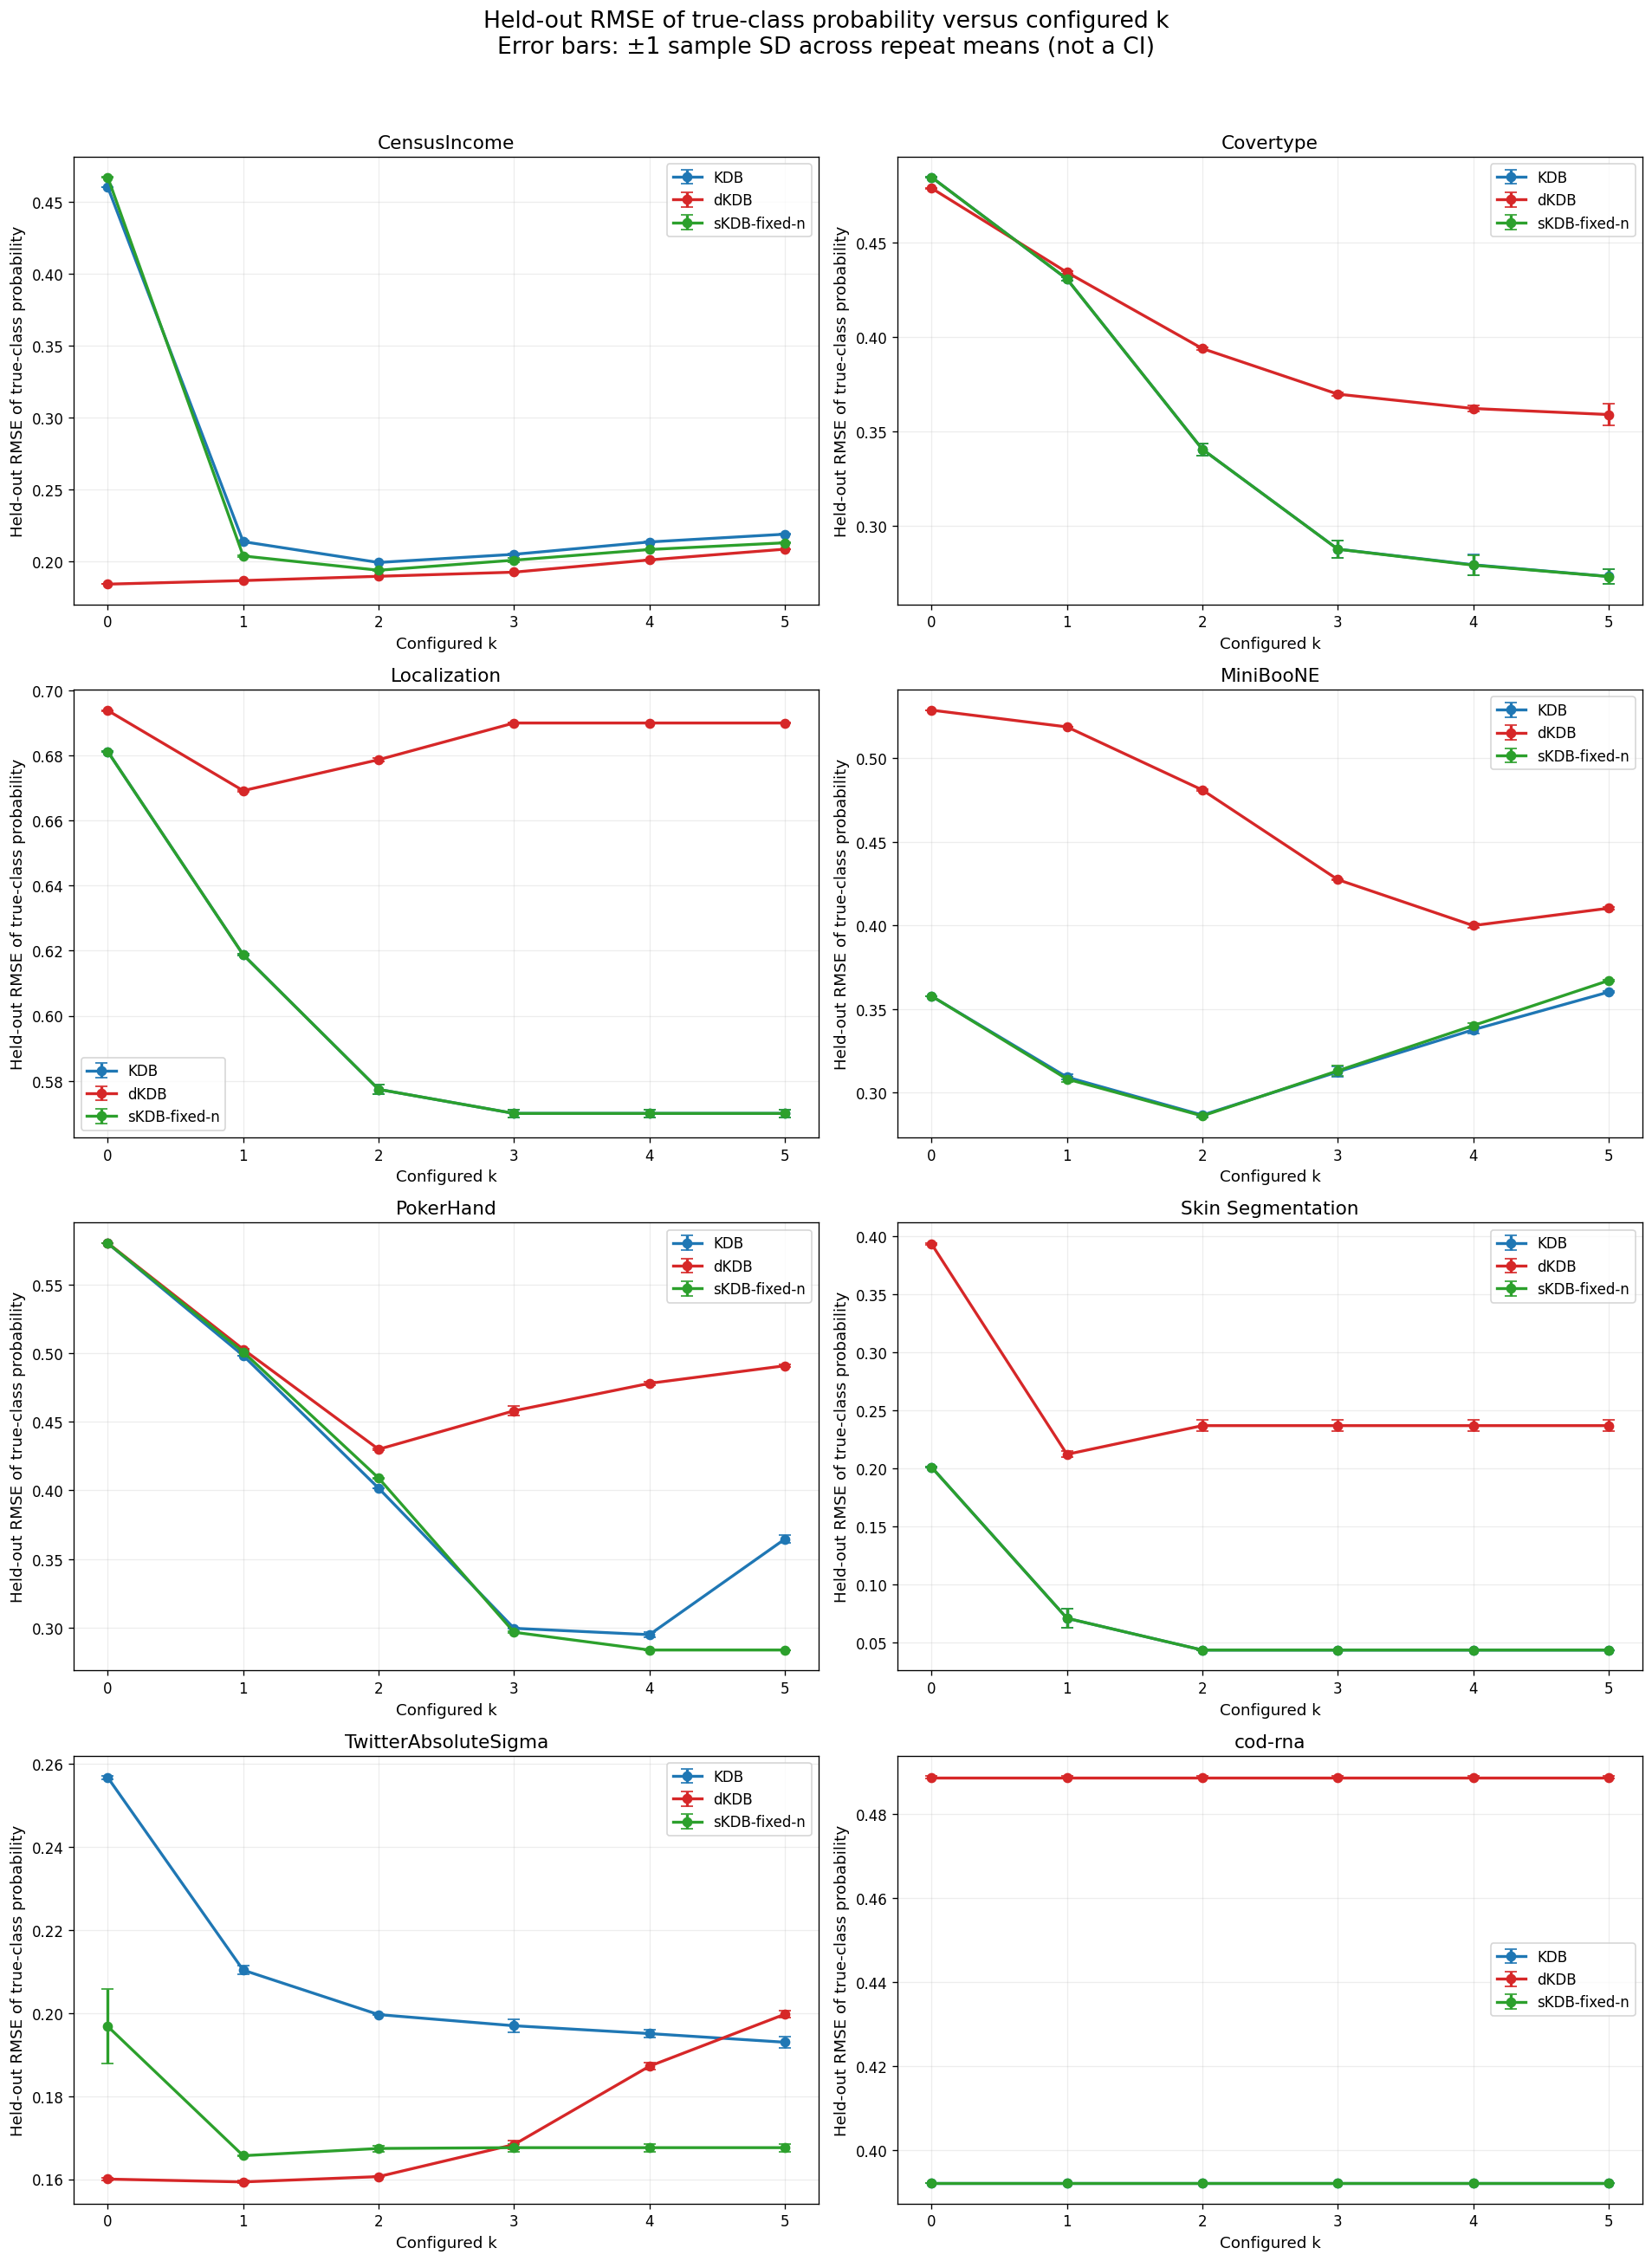

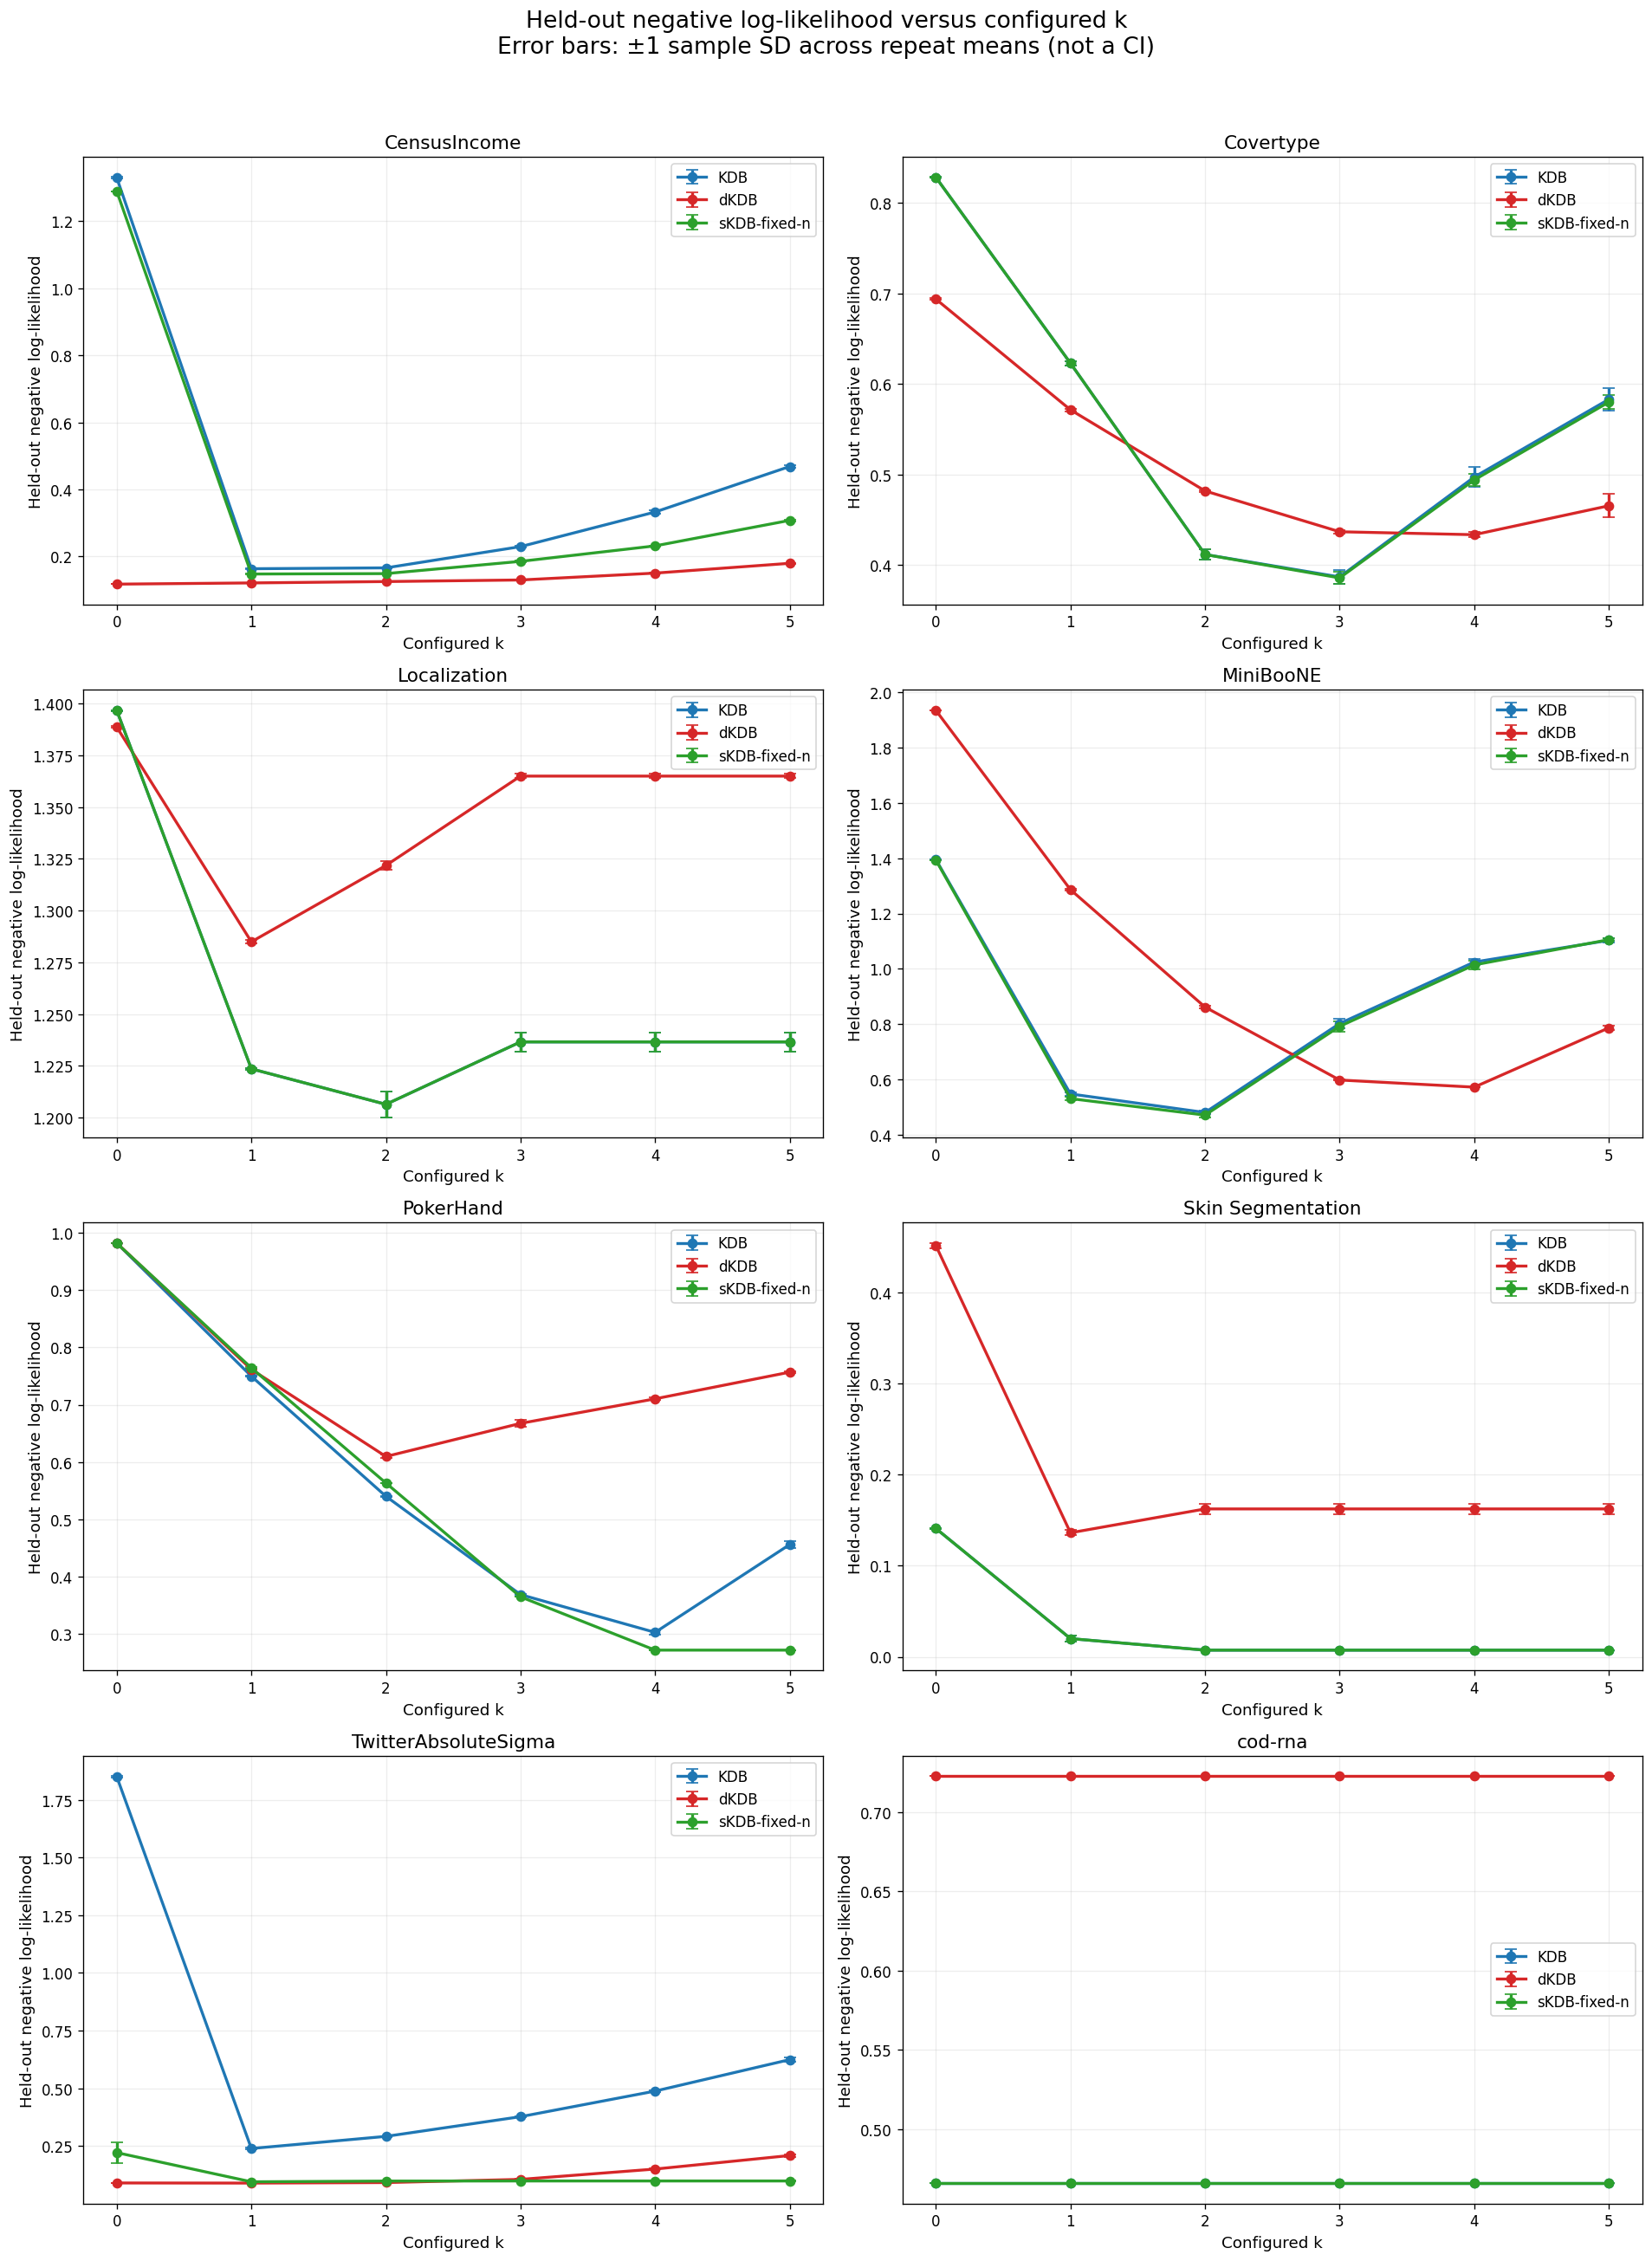

,dataset,learner,configured_k,mean,error,n_repeats,uncertainty_definition
0,CensusIncome,KDB,0,0.459977,0.000127,2,±1 sample SD across repeat means (not a CI)
1,CensusIncome,KDB,1,0.213585,0.000856,2,±1 sample SD across repeat means (not a CI)
2,CensusIncome,KDB,2,0.199108,0.000064,2,±1 sample SD across repeat means (not a CI)
3,CensusIncome,KDB,3,0.204774,0.000741,2,±1 sample SD across repeat means (not a CI)
4,CensusIncome,KDB,4,0.213367,0.000114,2,±1 sample SD across repeat means (not a CI)
...,...,...,...,...,...,...,...
139,cod-rna,sKDB-fixed-n,1,0.392222,0.000006,2,±1 sample SD across repeat means (not a CI)
140,cod-rna,sKDB-fixed-n,2,0.392222,0.000006,2,±1 sample SD across repeat means (not a CI)
141,cod-rna,sKDB-fixed-n,3,0.392222,0.000006,2,±1 sample SD across repeat means (not a CI)
142,cod-rna,sKDB-fixed-n,4,0.392222,0.000006,2,±1 sample SD across repeat means (not a CI)


,dataset,learner,configured_k,mean,error,n_repeats,uncertainty_definition
0,CensusIncome,KDB,0,1.329379,0.001956,2,±1 sample SD across repeat means (not a CI)
1,CensusIncome,KDB,1,0.163703,0.000925,2,±1 sample SD across repeat means (not a CI)
2,CensusIncome,KDB,2,0.166285,0.000017,2,±1 sample SD across repeat means (not a CI)
3,CensusIncome,KDB,3,0.229611,0.001813,2,±1 sample SD across repeat means (not a CI)
4,CensusIncome,KDB,4,0.332843,0.005508,2,±1 sample SD across repeat means (not a CI)
...,...,...,...,...,...,...,...
139,cod-rna,sKDB-fixed-n,1,0.466027,0.000002,2,±1 sample SD across repeat means (not a CI)
140,cod-rna,sKDB-fixed-n,2,0.466027,0.000002,2,±1 sample SD across repeat means (not a CI)
141,cod-rna,sKDB-fixed-n,3,0.466027,0.000002,2,±1 sample SD across repeat means (not a CI)
142,cod-rna,sKDB-fixed-n,4,0.466027,0.000002,2,±1 sample SD across repeat means (not a CI)


In [8]:
CONTROLLED_LEARNERS = [
    learner for learner in ("KDB", "dKDB", "sKDB-fixed-n")
    if learner in SELECTED_LEARNERS
]
PLOT_COLORS = {"KDB": "#1f77b4", "dKDB": "#d62728", "sKDB-fixed-n": "#2ca02c"}


def repeat_level_summary(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    required = {"dataset", "learner", "repeat", "fold", "configured_k", metric}
    if frame.empty or not required.issubset(frame.columns):
        return pd.DataFrame()
    controlled = frame[
        frame["learner"].isin(CONTROLLED_LEARNERS)
        & frame["configured_k"].notna()
    ].copy()
    repeat_means = (
        controlled.groupby(["dataset", "learner", "configured_k", "repeat"], as_index=False)[metric]
        .mean()
        .rename(columns={metric: "repeat_mean"})
    )
    rows = []
    for keys, group in repeat_means.groupby(["dataset", "learner", "configured_k"], sort=False):
        values = group["repeat_mean"].to_numpy(dtype=float)
        n = len(values)
        mean = float(values.mean())
        if n >= 3:
            spread = float(t.ppf(0.975, n - 1) * values.std(ddof=1) / np.sqrt(n))
            uncertainty = "95% t CI across repeat means"
        elif n == 2:
            spread = float(values.std(ddof=1))
            uncertainty = "±1 sample SD across repeat means (not a CI)"
        else:
            spread = 0.0
            uncertainty = "single repeat; no inferential error bar"
        rows.append({
            "dataset": keys[0], "learner": keys[1], "configured_k": int(keys[2]),
            "mean": mean, "error": spread, "n_repeats": n,
            "uncertainty_definition": uncertainty,
        })
    return pd.DataFrame(rows)


def plot_metric_vs_k(frame: pd.DataFrame, metric: str, ylabel: str):
    summary = repeat_level_summary(frame, metric)
    if summary.empty:
        print(f"No {metric} results available.")
        return summary, None
    datasets = list(dict.fromkeys(summary["dataset"]))
    columns = min(2, len(datasets))
    rows = math.ceil(len(datasets) / columns)
    figure, axes = plt.subplots(rows, columns, figsize=(8.0 * columns, 5.4 * rows), squeeze=False)
    for axis, dataset_name in zip(axes.ravel(), datasets):
        dataset_frame = summary[summary["dataset"] == dataset_name]
        for learner in CONTROLLED_LEARNERS:
            learner_frame = dataset_frame[dataset_frame["learner"] == learner].sort_values("configured_k")
            if learner_frame.empty:
                continue
            axis.errorbar(
                learner_frame["configured_k"], learner_frame["mean"],
                yerr=learner_frame["error"], marker="o", markersize=6,
                linewidth=2.0, capsize=4,
                label=learner, color=PLOT_COLORS[learner],
            )
        axis.set(title=dataset_name, xlabel="Configured k", ylabel=ylabel)
        axis.set_xticks(K_VALUES)
        axis.legend(fontsize=10)
    for axis in axes.ravel()[len(datasets):]:
        axis.axis("off")
    definition = "; ".join(summary["uncertainty_definition"].drop_duplicates())
    figure.suptitle(f"{ylabel} versus configured k\nError bars: {definition}", fontsize=16, y=1.005)
    figure.tight_layout(rect=(0, 0, 1, 0.985))
    safe_metric = metric.lower().replace(" ", "_")
    figure.savefig(EXPORT_DIRECTORY / f"plot_{safe_metric}_versus_k.png", dpi=200, bbox_inches="tight")
    figure.savefig(EXPORT_DIRECTORY / f"plot_{safe_metric}_versus_k.pdf", bbox_inches="tight")
    plt.show()
    return summary, figure


RMSE_K_SUMMARY, RMSE_FIGURE = plot_metric_vs_k(
    SUCCESSFUL_RUNS, "rmse", "Held-out RMSE of true-class probability"
)
NLL_K_SUMMARY, NLL_FIGURE = plot_metric_vs_k(
    SUCCESSFUL_RUNS, "nll", "Held-out negative log-likelihood"
)
display(RMSE_K_SUMMARY)
display(NLL_K_SUMMARY)


## 9. Paired deltas relative to KDB

Subtraction is performed for each matched dataset × repeat × fold × `k` before averaging. Negative values favor the variant on the same splits; positive values favor KDB. Error-bar overlap is not interpreted as a significance test.


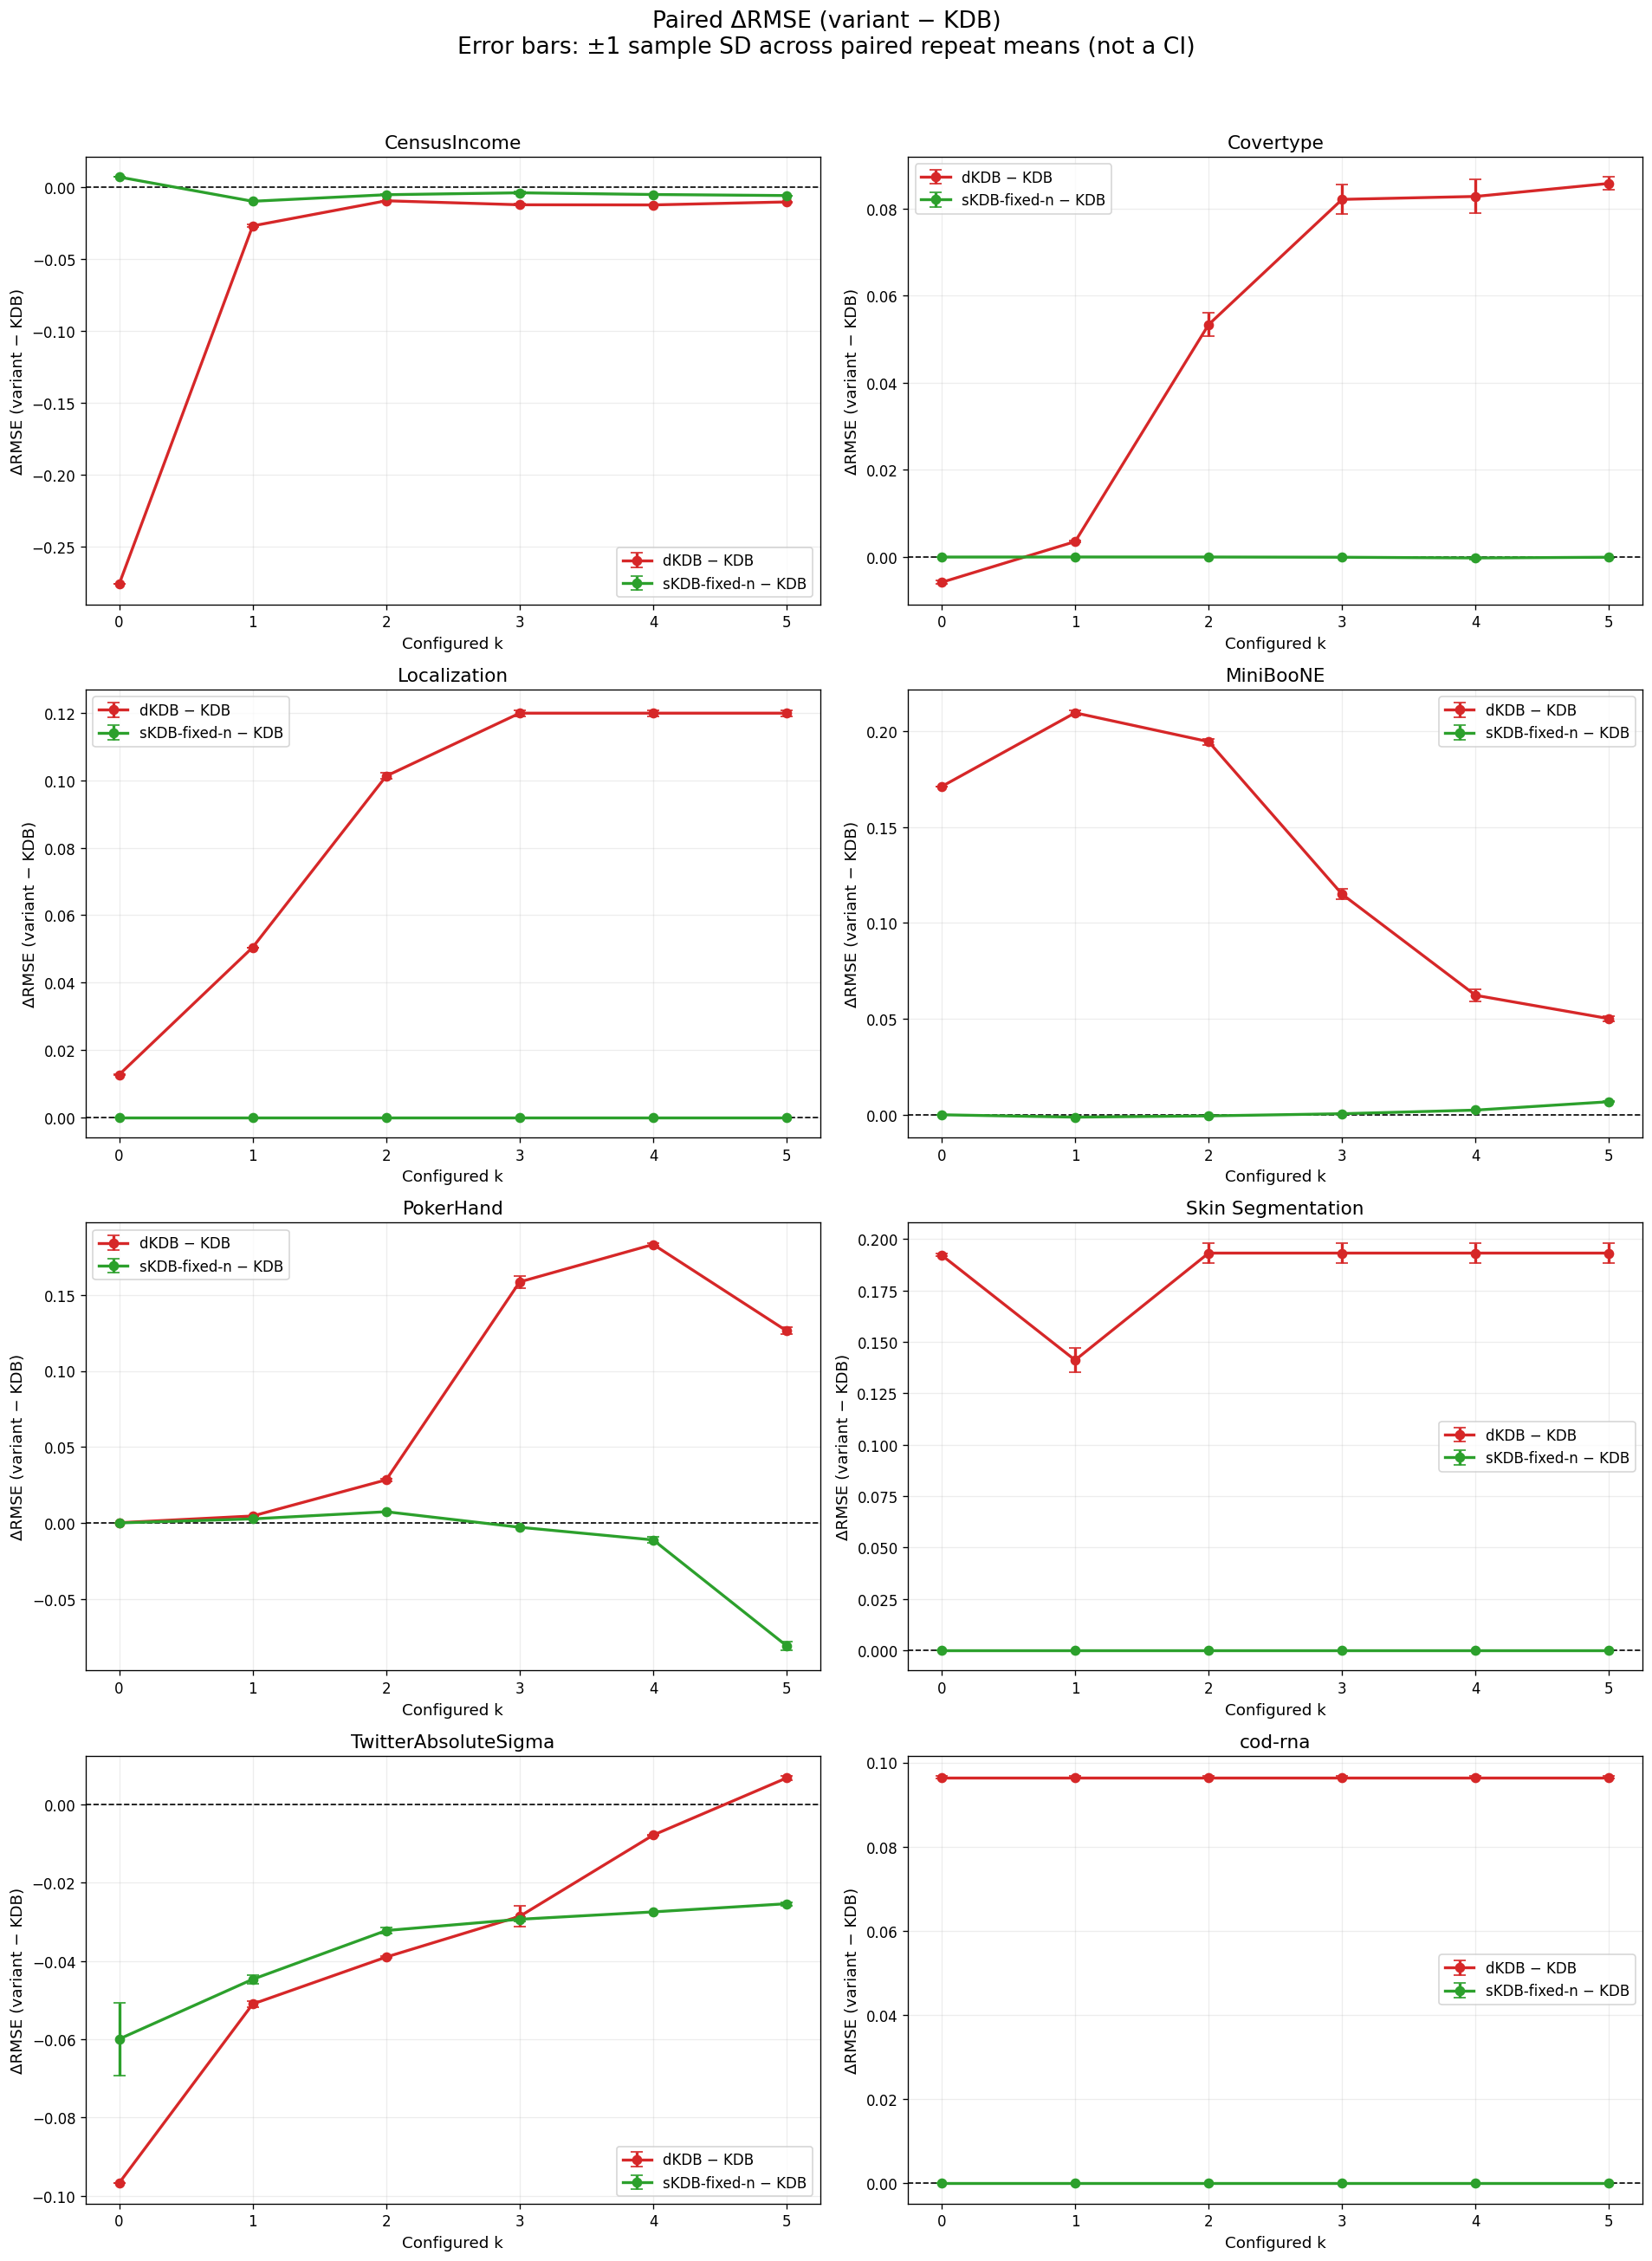

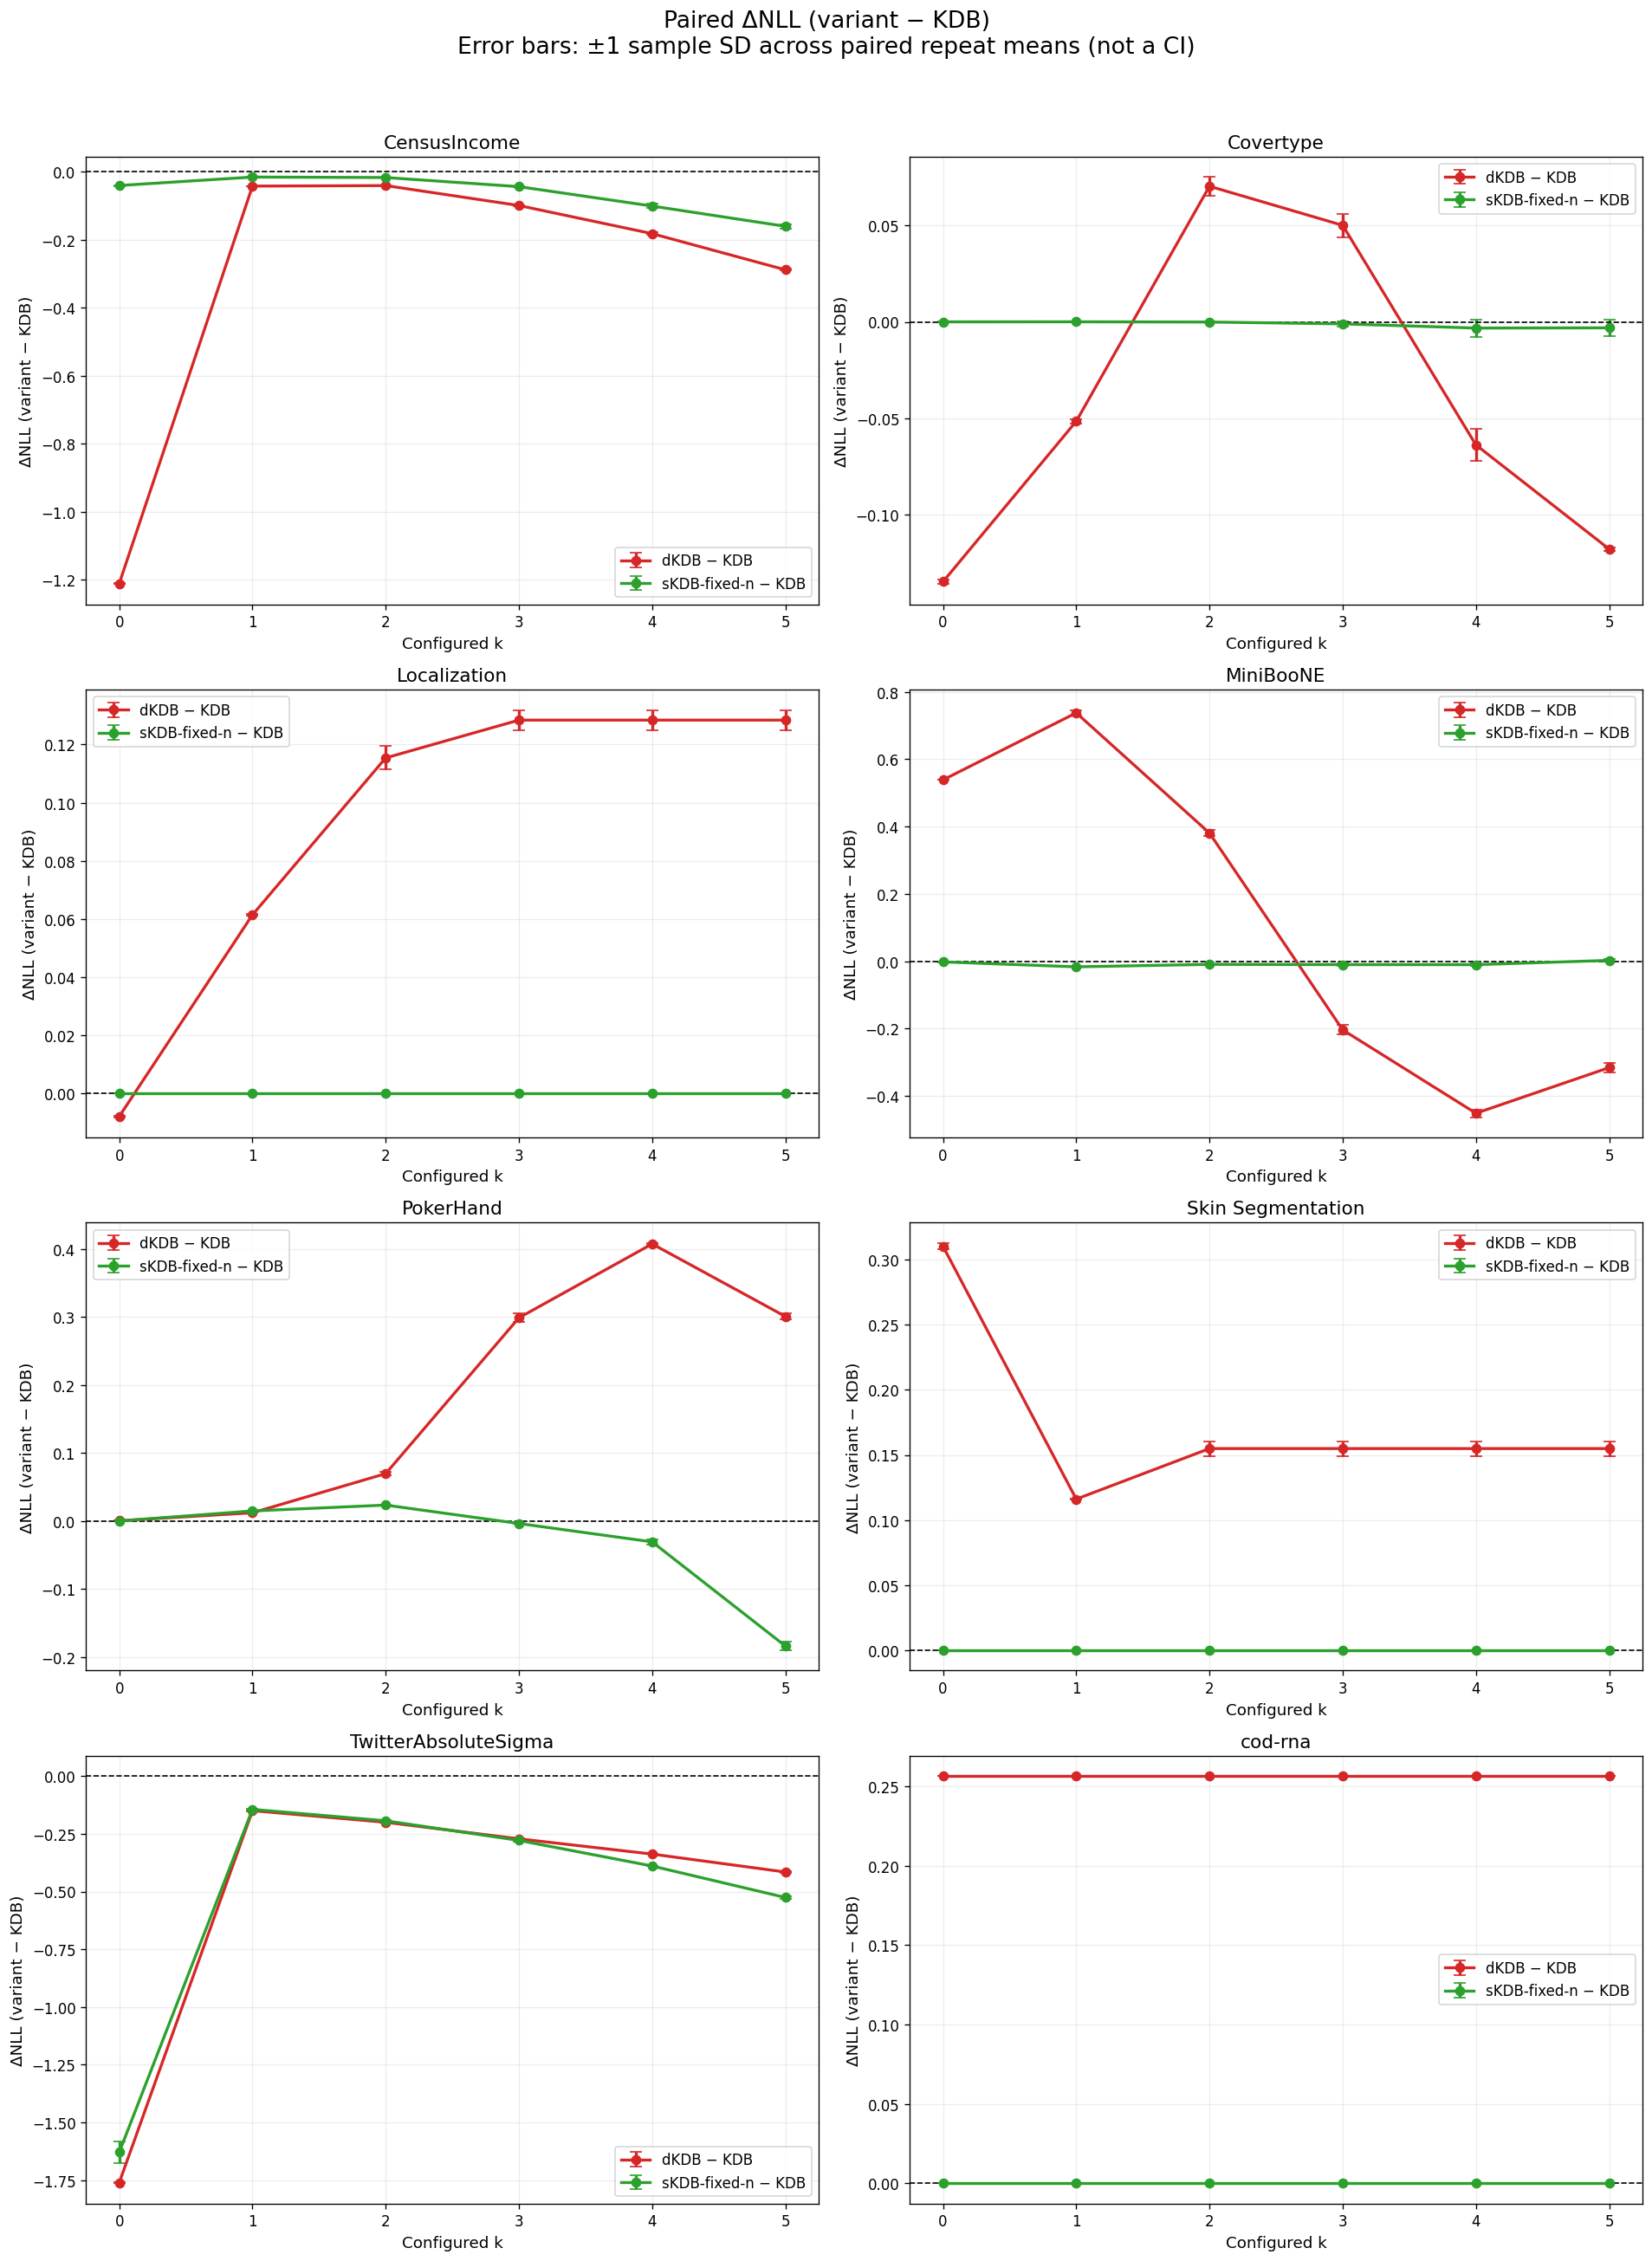

,dataset,learner,configured_k,mean_delta,error,n_repeats,uncertainty_definition
0,CensusIncome,dKDB,0,-0.275928,0.000114,2,±1 sample SD across paired repeat means (not a...
1,CensusIncome,dKDB,1,-0.027054,0.000791,2,±1 sample SD across paired repeat means (not a...
2,CensusIncome,dKDB,2,-0.009604,0.000141,2,±1 sample SD across paired repeat means (not a...
3,CensusIncome,dKDB,3,-0.012396,0.000563,2,±1 sample SD across paired repeat means (not a...
4,CensusIncome,dKDB,4,-0.012491,0.000251,2,±1 sample SD across paired repeat means (not a...
...,...,...,...,...,...,...,...
91,cod-rna,sKDB-fixed-n,1,0.000000,0.000000,2,±1 sample SD across paired repeat means (not a...
92,cod-rna,sKDB-fixed-n,2,0.000000,0.000000,2,±1 sample SD across paired repeat means (not a...
93,cod-rna,sKDB-fixed-n,3,0.000000,0.000000,2,±1 sample SD across paired repeat means (not a...
94,cod-rna,sKDB-fixed-n,4,0.000000,0.000000,2,±1 sample SD across paired repeat means (not a...


,dataset,learner,configured_k,mean_delta,error,n_repeats,uncertainty_definition
0,CensusIncome,dKDB,0,-1.211595,0.001879,2,±1 sample SD across paired repeat means (not a...
1,CensusIncome,dKDB,1,-0.042321,0.000798,2,±1 sample SD across paired repeat means (not a...
2,CensusIncome,dKDB,2,-0.040807,0.000134,2,±1 sample SD across paired repeat means (not a...
3,CensusIncome,dKDB,3,-0.099416,0.001465,2,±1 sample SD across paired repeat means (not a...
4,CensusIncome,dKDB,4,-0.182195,0.004249,2,±1 sample SD across paired repeat means (not a...
...,...,...,...,...,...,...,...
91,cod-rna,sKDB-fixed-n,1,0.000000,0.000000,2,±1 sample SD across paired repeat means (not a...
92,cod-rna,sKDB-fixed-n,2,0.000000,0.000000,2,±1 sample SD across paired repeat means (not a...
93,cod-rna,sKDB-fixed-n,3,0.000000,0.000000,2,±1 sample SD across paired repeat means (not a...
94,cod-rna,sKDB-fixed-n,4,0.000000,0.000000,2,±1 sample SD across paired repeat means (not a...


In [9]:
def paired_delta_rows(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    keys = ["dataset", "repeat", "fold", "split_id", "configured_k"]
    base = frame[(frame["learner"] == "KDB") & frame["configured_k"].notna()][keys + [metric]].rename(
        columns={metric: "kdb_value"}
    )
    variants = frame[
        frame["learner"].isin(["dKDB", "sKDB-fixed-n"])
        & frame["configured_k"].notna()
    ][keys + ["learner", metric]].rename(columns={metric: "variant_value"})
    paired = variants.merge(base, on=keys, how="inner", validate="many_to_one")
    paired["delta"] = paired["variant_value"] - paired["kdb_value"]
    paired["metric"] = metric
    return paired


def paired_delta_summary(frame: pd.DataFrame, metric: str) -> pd.DataFrame:
    paired = paired_delta_rows(frame, metric)
    if paired.empty:
        return pd.DataFrame()
    repeat_means = (
        paired.groupby(["dataset", "learner", "configured_k", "repeat"], as_index=False)["delta"]
        .mean().rename(columns={"delta": "repeat_delta"})
    )
    rows = []
    for keys, group in repeat_means.groupby(["dataset", "learner", "configured_k"], sort=False):
        values = group["repeat_delta"].to_numpy(dtype=float)
        n = len(values)
        if n >= 3:
            error = float(t.ppf(0.975, n - 1) * values.std(ddof=1) / np.sqrt(n))
            definition = "95% t CI across paired repeat means"
        elif n == 2:
            error = float(values.std(ddof=1))
            definition = "±1 sample SD across paired repeat means (not a CI)"
        else:
            error = 0.0
            definition = "single repeat; no inferential error bar"
        rows.append({
            "dataset": keys[0], "learner": keys[1], "configured_k": int(keys[2]),
            "mean_delta": float(values.mean()), "error": error,
            "n_repeats": n, "uncertainty_definition": definition,
        })
    return pd.DataFrame(rows)


def plot_paired_delta(frame: pd.DataFrame, metric: str, ylabel: str):
    summary = paired_delta_summary(frame, metric)
    if summary.empty:
        print(f"No paired {metric} deltas available.")
        return summary, None
    datasets = list(dict.fromkeys(summary["dataset"]))
    columns = min(2, len(datasets))
    rows = math.ceil(len(datasets) / columns)
    figure, axes = plt.subplots(rows, columns, figsize=(8.0 * columns, 5.4 * rows), squeeze=False)
    for axis, dataset_name in zip(axes.ravel(), datasets):
        dataset_frame = summary[summary["dataset"] == dataset_name]
        for learner in ("dKDB", "sKDB-fixed-n"):
            learner_frame = dataset_frame[dataset_frame["learner"] == learner].sort_values("configured_k")
            if learner_frame.empty:
                continue
            axis.errorbar(
                learner_frame["configured_k"], learner_frame["mean_delta"],
                yerr=learner_frame["error"], marker="o", markersize=6,
                linewidth=2.0, capsize=4,
                label=f"{learner} − KDB", color=PLOT_COLORS[learner],
            )
        axis.axhline(0.0, color="black", linewidth=1, linestyle="--")
        axis.set(title=dataset_name, xlabel="Configured k", ylabel=ylabel)
        axis.set_xticks(K_VALUES)
        axis.legend(fontsize=10)
    for axis in axes.ravel()[len(datasets):]:
        axis.axis("off")
    definition = "; ".join(summary["uncertainty_definition"].drop_duplicates())
    figure.suptitle(f"Paired {ylabel}\nError bars: {definition}", fontsize=16, y=1.005)
    figure.tight_layout(rect=(0, 0, 1, 0.985))
    safe_metric = metric.lower().replace(" ", "_")
    figure.savefig(EXPORT_DIRECTORY / f"plot_paired_delta_{safe_metric}.png", dpi=200, bbox_inches="tight")
    figure.savefig(EXPORT_DIRECTORY / f"plot_paired_delta_{safe_metric}.pdf", bbox_inches="tight")
    plt.show()
    return summary, figure


PAIRED_RMSE_ROWS = paired_delta_rows(SUCCESSFUL_RUNS, "rmse")
PAIRED_NLL_ROWS = paired_delta_rows(SUCCESSFUL_RUNS, "nll")
PAIRED_RMSE_SUMMARY, PAIRED_RMSE_FIGURE = plot_paired_delta(
    SUCCESSFUL_RUNS, "rmse", "ΔRMSE (variant − KDB)"
)
PAIRED_NLL_SUMMARY, PAIRED_NLL_FIGURE = plot_paired_delta(
    SUCCESSFUL_RUNS, "nll", "ΔNLL (variant − KDB)"
)
display(PAIRED_RMSE_SUMMARY)
display(PAIRED_NLL_SUMMARY)


## 10. Native sKDB selection stability

The feature count and dependency order below are the actual training-fold-only native sKDB choices. `sKDB-fixed-n` is never substituted for these native results.


C:\Users\anagh\AppData\Local\Temp\ipykernel_36412\3649929142.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(values, vert=False, labels=datasets, showmeans=True)


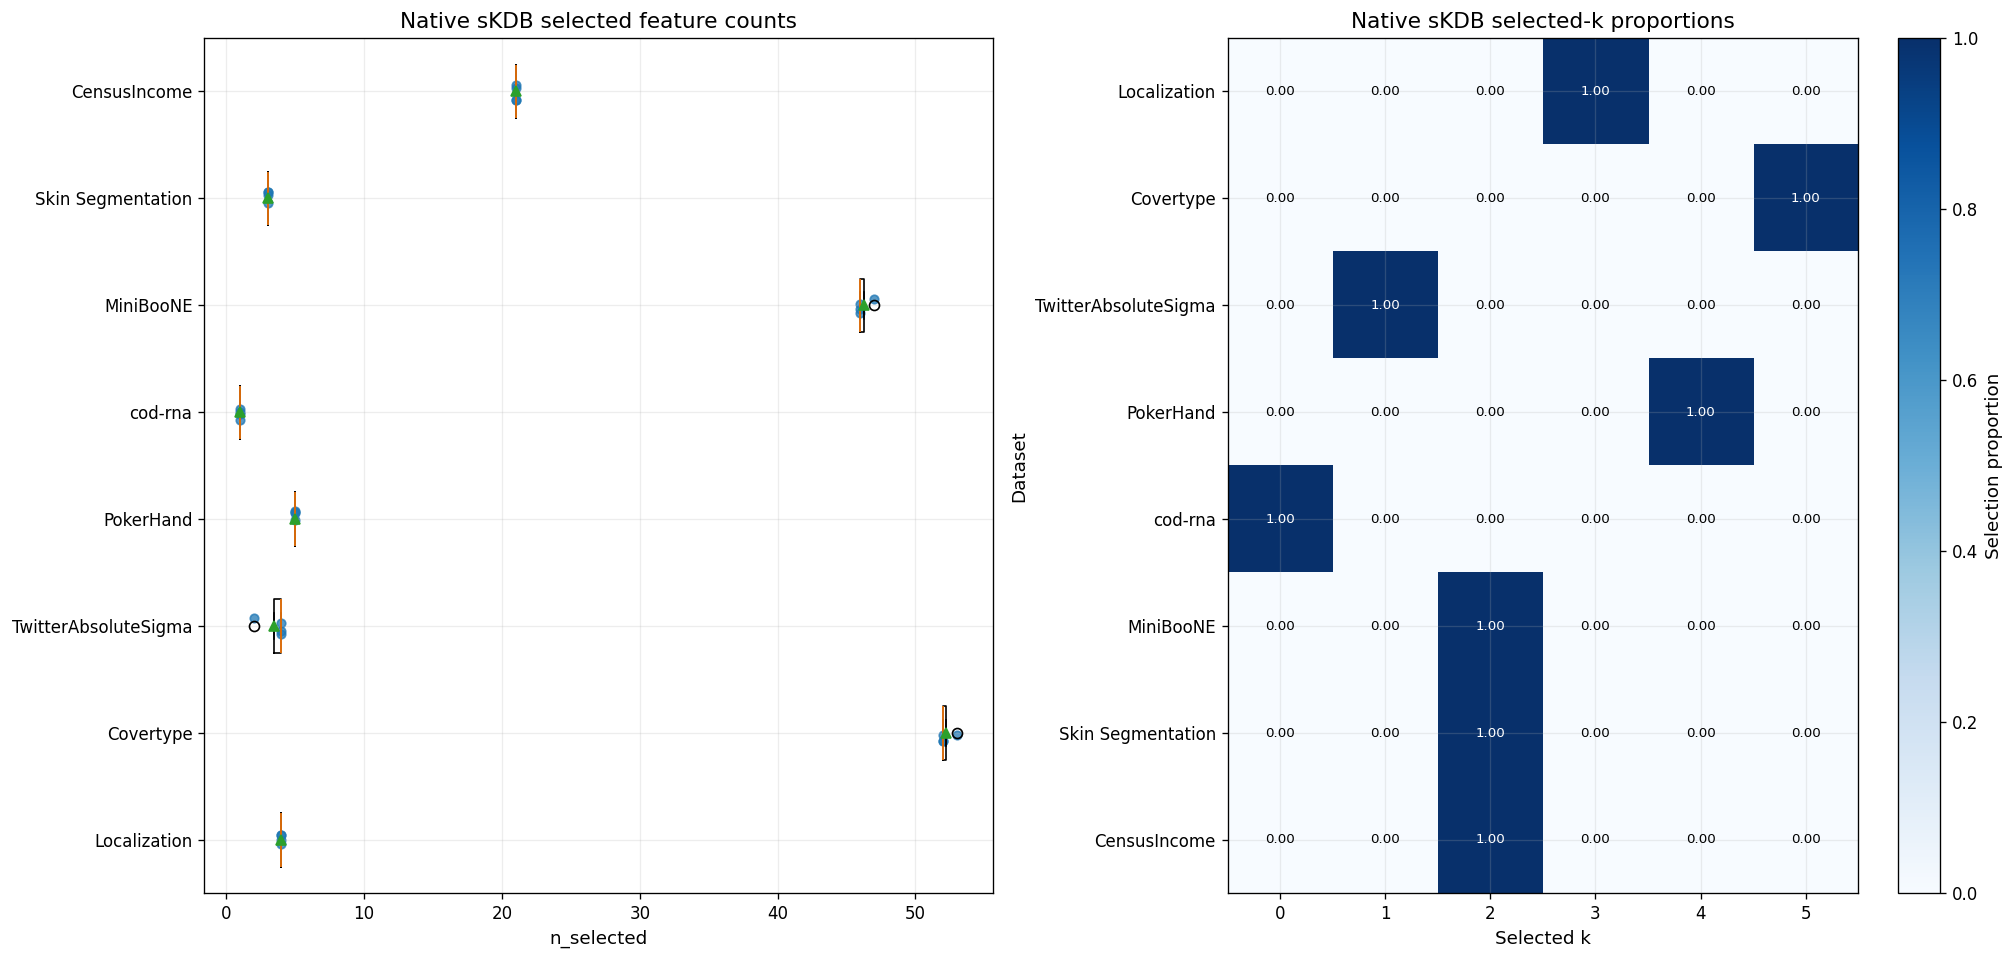

,dataset,selected_k,count,proportion
0,CensusIncome,2,4,1.0
1,Covertype,5,4,1.0
2,Localization,3,4,1.0
3,MiniBooNE,2,4,1.0
4,PokerHand,4,4,1.0
5,Skin Segmentation,2,4,1.0
6,TwitterAbsoluteSigma,1,4,1.0
7,cod-rna,0,4,1.0


In [10]:
if NATIVE_SELECTIONS.empty:
    print("No native sKDB selection records are available.")
    NATIVE_K_FREQUENCY = pd.DataFrame()
else:
    selection_plot_data = NATIVE_SELECTIONS[NATIVE_SELECTIONS["status"] == "complete"].copy()
    datasets = list(dict.fromkeys(selection_plot_data["dataset"]))
    figure, axes = plt.subplots(1, 2, figsize=(17, max(6.5, 0.70 * len(datasets) + 2.5)))

    values = [selection_plot_data.loc[selection_plot_data["dataset"] == name, "n_selected"].to_numpy()
              for name in datasets]
    axes[0].boxplot(values, vert=False, labels=datasets, showmeans=True)
    jitter_rng = np.random.default_rng(RANDOM_SEED)
    for position, dataset_values in enumerate(values, start=1):
        axes[0].scatter(
            dataset_values,
            position + jitter_rng.uniform(-0.08, 0.08, size=len(dataset_values)),
            s=26, alpha=0.75, color="#1f77b4",
        )
    axes[0].set(title="Native sKDB selected feature counts", xlabel="n_selected")

    NATIVE_K_FREQUENCY = (
        selection_plot_data.groupby(["dataset", "selected_k"]).size()
        .rename("count").reset_index()
    )
    totals = NATIVE_K_FREQUENCY.groupby("dataset")["count"].transform("sum")
    NATIVE_K_FREQUENCY["proportion"] = NATIVE_K_FREQUENCY["count"] / totals
    frequency_matrix = (
        NATIVE_K_FREQUENCY.pivot(index="dataset", columns="selected_k", values="proportion")
        .reindex(index=datasets, columns=K_VALUES, fill_value=0.0).fillna(0.0)
    )
    image = axes[1].imshow(frequency_matrix.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="Blues")
    axes[1].set(
        title="Native sKDB selected-k proportions",
        xlabel="Selected k", ylabel="Dataset",
        xticks=np.arange(len(K_VALUES)), xticklabels=K_VALUES,
        yticks=np.arange(len(datasets)), yticklabels=datasets,
    )
    for row_index in range(frequency_matrix.shape[0]):
        for column_index in range(frequency_matrix.shape[1]):
            value = frequency_matrix.iat[row_index, column_index]
            axes[1].text(column_index, row_index, f"{value:.2f}", ha="center", va="center",
                         color="white" if value > 0.55 else "black", fontsize=8)
    figure.colorbar(image, ax=axes[1], label="Selection proportion")
    figure.tight_layout()
    figure.savefig(EXPORT_DIRECTORY / "plot_native_skdb_selection_stability.png", dpi=200, bbox_inches="tight")
    figure.savefig(EXPORT_DIRECTORY / "plot_native_skdb_selection_stability.pdf", bbox_inches="tight")
    plt.show()
    display(NATIVE_K_FREQUENCY)


## 11. Required summary tables

All values below are derived from unrounded fold-level records. High-`k` degradation is descriptive evidence, not by itself a significance or causal claim.


In [11]:
def build_main_k_summary(frame: pd.DataFrame) -> pd.DataFrame:
    controlled = frame[
        frame["learner"].isin(CONTROLLED_LEARNERS)
        & frame["configured_k"].notna()
    ]
    means = (
        controlled.groupby(["dataset", "learner", "configured_k"], as_index=False)
        .agg(mean_rmse=("rmse", "mean"), mean_nll=("nll", "mean"))
    )
    rows = []
    for (dataset_name, learner), group in means.groupby(["dataset", "learner"], sort=False):
        group = group.sort_values("configured_k")
        rmse_best = group.loc[group["mean_rmse"].idxmin()]
        nll_best = group.loc[group["mean_nll"].idxmin()]
        high = group[group["configured_k"] == 5]
        high_rmse = float(high.iloc[0]["mean_rmse"]) if len(high) else np.nan
        high_nll = float(high.iloc[0]["mean_nll"]) if len(high) else np.nan
        rows.append({
            "dataset": dataset_name,
            "learner": learner,
            "best_mean_rmse_k": int(rmse_best["configured_k"]),
            "best_mean_rmse": float(rmse_best["mean_rmse"]),
            "rmse_at_k5": high_rmse,
            "rmse_k5_minus_best": high_rmse - float(rmse_best["mean_rmse"]),
            "best_mean_nll_k": int(nll_best["configured_k"]),
            "best_mean_nll": float(nll_best["mean_nll"]),
            "nll_at_k5": high_nll,
            "nll_k5_minus_best": high_nll - float(nll_best["mean_nll"]),
        })
    return pd.DataFrame(rows)


MAIN_K_SENSITIVITY_SUMMARY = build_main_k_summary(SUCCESSFUL_RUNS)


def build_direct_high_k_comparison(main_summary: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for dataset_name, group in main_summary.groupby("dataset", sort=False):
        kdb = group[group["learner"] == "KDB"]
        dkdb = group[group["learner"] == "dKDB"]
        if kdb.empty or dkdb.empty:
            continue
        kdb, dkdb = kdb.iloc[0], dkdb.iloc[0]
        rows.append({
            "dataset": dataset_name,
            "best_kdb_k_rmse": int(kdb["best_mean_rmse_k"]),
            "best_dkdb_k_rmse": int(dkdb["best_mean_rmse_k"]),
            "kdb_high_k_rmse_degradation": float(kdb["rmse_k5_minus_best"]),
            "dkdb_high_k_rmse_degradation": float(dkdb["rmse_k5_minus_best"]),
            "excess_dkdb_rmse_degradation": float(dkdb["rmse_k5_minus_best"] - kdb["rmse_k5_minus_best"]),
            "best_kdb_k_nll": int(kdb["best_mean_nll_k"]),
            "best_dkdb_k_nll": int(dkdb["best_mean_nll_k"]),
            "kdb_high_k_nll_degradation": float(kdb["nll_k5_minus_best"]),
            "dkdb_high_k_nll_degradation": float(dkdb["nll_k5_minus_best"]),
            "excess_dkdb_nll_degradation": float(dkdb["nll_k5_minus_best"] - kdb["nll_k5_minus_best"]),
        })
    return pd.DataFrame(rows)


DIRECT_DKDB_KDB_HIGH_K = build_direct_high_k_comparison(MAIN_K_SENSITIVITY_SUMMARY)


def build_native_selection_summary(selections: pd.DataFrame, runs: pd.DataFrame) -> pd.DataFrame:
    if selections.empty:
        return pd.DataFrame()
    native_scores = runs[runs["learner"] == "sKDB-native"].groupby("dataset", as_index=False).agg(
        native_mean_rmse=("rmse", "mean"), native_mean_nll=("nll", "mean")
    )
    rows = []
    for dataset_name, group in selections[selections["status"] == "complete"].groupby("dataset", sort=False):
        counts = group["selected_k"].value_counts().sort_index()
        selected = group["n_selected"].to_numpy(dtype=float)
        total_features = int(group["n_total_features"].iloc[0])
        modes = counts[counts == counts.max()].index.astype(int).tolist()
        rows.append({
            "dataset": dataset_name,
            "n_total_features": total_features,
            "n_selected_median": float(np.median(selected)),
            "n_selected_mean": float(np.mean(selected)),
            "n_selected_min": int(np.min(selected)),
            "n_selected_max": int(np.max(selected)),
            "n_selected_fraction_median": float(np.median(selected / total_features)),
            "selected_k_mode_json": json.dumps(modes),
            "selected_k_frequency_json": json.dumps({int(k): int(v) for k, v in counts.items()}),
            "selection_count": len(group),
        })
    return pd.DataFrame(rows).merge(native_scores, on="dataset", how="left")


NATIVE_SKDB_SELECTION_SUMMARY = build_native_selection_summary(
    NATIVE_SELECTIONS, SUCCESSFUL_RUNS
)

print("TABLE 1 — Main k-sensitivity summary")
display(MAIN_K_SENSITIVITY_SUMMARY)
print("TABLE 2 — Direct dKDB vs KDB high-k comparison")
display(DIRECT_DKDB_KDB_HIGH_K)
print("TABLE 3 — Native sKDB selection summary")
display(NATIVE_SKDB_SELECTION_SUMMARY)


TABLE 1 — Main k-sensitivity summary


,dataset,learner,best_mean_rmse_k,best_mean_rmse,rmse_at_k5,rmse_k5_minus_best,best_mean_nll_k,best_mean_nll,nll_at_k5,nll_k5_minus_best
0,CensusIncome,KDB,2,0.199108,0.218765,0.019656,1,0.163703,0.468456,0.304753
1,CensusIncome,dKDB,0,0.184049,0.208360,0.024311,0,0.117784,0.179851,0.062067
2,CensusIncome,sKDB-fixed-n,2,0.193710,0.212781,0.019071,1,0.147963,0.307823,0.159860
3,Covertype,KDB,5,0.272972,0.272972,0.000000,3,0.386730,0.583019,0.196288
4,Covertype,dKDB,5,0.358750,0.358750,0.000000,4,0.433422,0.465379,0.031957
5,Covertype,sKDB-fixed-n,5,0.272930,0.272930,0.000000,3,0.385677,0.579911,0.194235
6,Localization,KDB,3,0.569995,0.569995,0.000000,2,1.206378,1.236539,0.030161
7,Localization,dKDB,1,0.669148,0.689934,0.020786,1,1.284898,1.364961,0.080064
8,Localization,sKDB-fixed-n,3,0.569995,0.569995,0.000000,2,1.206378,1.236539,0.030161
9,MiniBooNE,KDB,2,0.286587,0.360168,0.073581,2,0.481450,1.103109,0.621659


TABLE 2 — Direct dKDB vs KDB high-k comparison


,dataset,best_kdb_k_rmse,best_dkdb_k_rmse,kdb_high_k_rmse_degradation,dkdb_high_k_rmse_degradation,excess_dkdb_rmse_degradation,best_kdb_k_nll,best_dkdb_k_nll,kdb_high_k_nll_degradation,dkdb_high_k_nll_degradation,excess_dkdb_nll_degradation
0,CensusIncome,2,0,0.019656,0.024311,0.004654,1,0,0.304753,0.062067,-0.242687
1,Covertype,5,5,0.000000,0.000000,0.000000,3,4,0.196288,0.031957,-0.164331
2,Localization,3,1,0.000000,0.020786,0.020786,2,1,0.030161,0.080064,0.049902
3,MiniBooNE,2,4,0.073581,0.010367,-0.063214,2,4,0.621659,0.214067,-0.407592
4,PokerHand,4,2,0.069674,0.060873,-0.008801,4,2,0.153194,0.147068,-0.006125
5,Skin Segmentation,2,1,0.000000,0.024696,0.024696,2,1,0.000000,0.026174,0.026174
6,TwitterAbsoluteSigma,5,1,0.000000,0.040375,0.040375,1,1,0.385069,0.119387,-0.265682
7,cod-rna,0,0,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000


TABLE 3 — Native sKDB selection summary


,dataset,n_total_features,n_selected_median,n_selected_mean,n_selected_min,n_selected_max,n_selected_fraction_median,selected_k_mode_json,selected_k_frequency_json,selection_count,native_mean_rmse,native_mean_nll
0,Localization,4,4.0,4.00,4,4,1.000000,[3],"{""3"": 4}",4,0.569995,1.236539
1,Covertype,54,52.0,52.25,52,53,0.962963,[5],"{""5"": 4}",4,0.272930,0.579911
2,TwitterAbsoluteSigma,77,4.0,3.50,2,4,0.051948,[1],"{""1"": 4}",4,0.165653,0.094872
3,PokerHand,10,5.0,5.00,5,5,0.500000,[4],"{""4"": 4}",4,0.283610,0.272026
4,cod-rna,8,1.0,1.00,1,1,0.125000,[0],"{""0"": 4}",4,0.392222,0.466027
5,MiniBooNE,50,46.0,46.25,46,47,0.920000,[2],"{""2"": 4}",4,0.286095,0.471981
6,Skin Segmentation,3,3.0,3.00,3,3,1.000000,[2],"{""2"": 4}",4,0.043543,0.007302
7,CensusIncome,40,21.0,21.00,21,21,0.525000,[2],"{""2"": 4}",4,0.193710,0.149162


## 12. Structural, backoff, optimizer, and prediction-sensitivity diagnostics

The implementation exposes parent lists, context tables, pass counts, iteration count, and update count. It does **not** expose an optimization objective, gradient norm, or convergence flag; those fields are recorded as unavailable rather than invented.


In [12]:
STRUCTURAL_DIAGNOSTICS_COLUMNS = [
    "dataset", "learner", "repeat", "fold", "configured_k", "effective_k",
    "parent_counts_json", "mean_parent_count", "median_parent_count", "max_parent_count",
    "n_attributes_full_configured_k", "full_context_available_fraction", "backoff_fraction",
    "mean_requested_context_order", "mean_effective_context_order",
    "effective_context_order_histogram", "dkdb_backoff_corrections",
    "dkdb_backoff_correction_fraction", "optimization_iterations", "optimization_updates",
    "optimization_objective", "optimization_convergence_status", "structure_sha256",
    "prediction_sha256", "max_abs_probability_difference_vs_k0",
    "max_abs_probability_difference_vs_previous_k",
]
STRUCTURAL_DIAGNOSTICS = SUCCESSFUL_RUNS[
    [column for column in STRUCTURAL_DIAGNOSTICS_COLUMNS if column in SUCCESSFUL_RUNS.columns]
].copy()

print("Per-fold structural/backoff diagnostics")
display(STRUCTURAL_DIAGNOSTICS)
print("Across-k structure/prediction diagnostics")
display(PREDICTION_DIAGNOSTICS)

if not SUCCESSFUL_RUNS.empty and "dkdb_backoff_corrections" in SUCCESSFUL_RUNS:
    DKDB_BACKOFF_SUMMARY = (
        SUCCESSFUL_RUNS[SUCCESSFUL_RUNS["learner"] == "dKDB"]
        .groupby(["dataset", "configured_k"], as_index=False)
        .agg(
            mean_backoff_fraction=("backoff_fraction", "mean"),
            mean_correction_fraction=("dkdb_backoff_correction_fraction", "mean"),
            total_corrected_factor_lookups=("dkdb_backoff_corrections", "sum"),
            mean_effective_context_order=("mean_effective_context_order", "mean"),
        )
    )
else:
    DKDB_BACKOFF_SUMMARY = pd.DataFrame()
display(DKDB_BACKOFF_SUMMARY)


Per-fold structural/backoff diagnostics


,dataset,learner,repeat,fold,configured_k,effective_k,parent_counts_json,mean_parent_count,median_parent_count,max_parent_count,n_attributes_full_configured_k,full_context_available_fraction,backoff_fraction,mean_requested_context_order,mean_effective_context_order,effective_context_order_histogram,dkdb_backoff_corrections,dkdb_backoff_correction_fraction,optimization_iterations,optimization_updates,optimization_objective,optimization_convergence_status,structure_sha256,prediction_sha256,max_abs_probability_difference_vs_k0,max_abs_probability_difference_vs_previous_k
0,Localization,KDB,1,1,2.0,2,"[0, 1, 2, 2]",1.250000,1.5,2,2,0.999798,0.000202,1.250000,1.249848,"{""0"": 82430, ""1"": 82480, ""2"": 164810}",0,0.000000,0,0,None,None,2e80984a2d1f88f6edb05b7b73b84f517fafdae7c05f4c...,667ec4b022d35e73ebbc3d5880529f75eb2c18518cadd9...,0.990313,0.993359
1,TwitterAbsoluteSigma,KDB,2,1,5.0,5,"[0, 1, 2, 3, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...",4.805195,5.0,5,72,0.959540,0.040460,4.805195,4.742204,"{""0"": 70354, ""1"": 72298, ""2"": 93880, ""3"": 1426...",0,0.000000,0,0,None,None,80bed6212e78527b6973413ddac7d9ad7bea8616b51a6a...,9b5c407a42c5fcf047803ce1ccdb93bb02513db49806df...,1.000000,0.999996
2,cod-rna,KDB,2,1,3.0,3,"[0, 1, 2, 3, 3, 3, 3, 3]",2.250000,3.0,3,5,1.000000,0.000000,2.250000,2.250000,"{""0"": 244283, ""1"": 244283, ""2"": 244283, ""3"": 1...",0,0.000000,0,0,None,None,942e5887af2fabd218d0312be47fc7d5a3054454d07ab1...,4550e7dd8486d976d9a596aadf4c521643478a32537682...,0.000000,0.000000
3,PokerHand,KDB,2,2,2.0,2,"[0, 1, 2, 2, 2, 2, 2, 2, 2, 2]",1.700000,2.0,2,8,1.000000,0.000000,1.700000,1.700000,"{""0"": 512505, ""1"": 512505, ""2"": 4100040}",0,0.000000,0,0,None,None,ef85c6911a2cc72866906fa909d44f5f82b08c3ff8da92...,f7688a75cef8fe70577140f81f4dddd42e7a22a88796f9...,0.981123,0.916647
4,Localization,sKDB-native,2,2,NaN,3,"[0, 1, 2, 3]",1.500000,1.5,3,1,0.993146,0.006854,1.500000,1.494723,"{""0"": 82430, ""1"": 82520, ""2"": 83990, ""3"": 80780}",0,0.000000,0,0,None,None,3ed21bdaccfb2e8924ce3b8bf8aed9d50e78725c73fd3c...,00981c53f39e515a83b5583dcc1e5b061523dcf4be8c78...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
603,Covertype,sKDB-fixed-n,2,1,3.0,3,"[0, 1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...",2.884615,3.0,3,49,0.998833,0.001167,2.884615,2.883452,"{""0"": 290506, ""1"": 290792, ""2"": 307507, ""3"": 1...",0,0.000000,0,0,None,None,cb145fe93354995b230126ced009819b61358f528e3c0a...,7e215584ef43eed202e71067384ee5c22d906b14d993c0...,1.000000,0.999915
604,Skin Segmentation,KDB,2,1,2.0,2,"[0, 1, 2]",1.000000,1.0,2,1,0.999792,0.000208,1.000000,0.999861,"{""0"": 122529, ""1"": 122580, ""2"": 122478}",0,0.000000,0,0,None,None,13f9fa321882030cb06c826cd0105876d8f64c625809aa...,8c9479e2d6f8bba8902440aa1761a76ba463eee962e09d...,0.999751,0.970877
605,PokerHand,KDB,2,2,1.0,1,"[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]",0.900000,1.0,1,9,1.000000,0.000000,0.900000,0.900000,"{""0"": 512505, ""1"": 4612545}",0,0.000000,0,0,None,None,77e615898ac873e1bc39f91bc1dbed66fe2d916e2d8a8c...,f3f5b10f0613035ddd14fa64d2dda89b567ee5e256ba8d...,0.828022,0.828022
606,cod-rna,dKDB,2,1,2.0,2,"[0, 1, 2, 2, 2, 2, 2, 2]",1.625000,2.0,2,6,1.000000,0.000000,1.625000,1.625000,"{""0"": 244283, ""1"": 244283, ""2"": 1465698}",0,0.000000,1,244282,None,not exposed by implementation,f2bb0842e49facdde83622a48f78491067fe45d63239c2...,abd15e80bfecef4396a7e9f0ad1e6ef172fb7551a0ac07...,0.000000,0.000000


Across-k structure/prediction diagnostics


,configuration_id,dataset,fold,identical_predictions_all_k,learner,max_abs_probability_difference_across_k_vs_k0,max_abs_probability_difference_adjacent_k,repeat,split_id,status,structure_hash_by_k_json,successful_k_values_json,unique_structure_count
0,ac255f2a40133425e871,cod-rna,1,True,sKDB-fixed-n,0.000000,0.000000,2,"repeat=2,fold=1",complete,"{""0"": ""e466d3adb6c3e1acfaefc21b2046ce2710e24ac...","[0, 1, 2, 3, 4, 5]",1
1,ac255f2a40133425e871,CensusIncome,1,False,KDB,1.000000,0.999954,1,"repeat=1,fold=1",complete,"{""0"": ""61a83210feeb65ae583632fe54375947271c48b...","[0, 1, 2, 3, 4, 5]",6
2,ac255f2a40133425e871,Covertype,1,False,KDB,1.000000,0.999988,1,"repeat=1,fold=1",complete,"{""0"": ""e52557c8b0082e0c757b8a17c0d589976b28fd8...","[0, 1, 2, 3, 4, 5]",6
3,ac255f2a40133425e871,Localization,2,False,dKDB,0.930262,0.722390,2,"repeat=2,fold=2",complete,"{""0"": ""b24eb3e0b4f97bc948767862270e34a98cefdab...","[0, 1, 2, 3, 4, 5]",4
4,ac255f2a40133425e871,Localization,2,False,KDB,0.997788,0.997788,2,"repeat=2,fold=2",complete,"{""0"": ""b24eb3e0b4f97bc948767862270e34a98cefdab...","[0, 1, 2, 3, 4, 5]",4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,ac255f2a40133425e871,Skin Segmentation,1,False,KDB,0.999804,0.999804,1,"repeat=1,fold=1",complete,"{""0"": ""6ad42d10abe6cb18a9026189931c0f8456523a0...","[0, 1, 2, 3, 4, 5]",3
92,ac255f2a40133425e871,TwitterAbsoluteSigma,2,False,KDB,1.000000,1.000000,1,"repeat=1,fold=2",complete,"{""0"": ""be8a706b49c775983c4e5c88fb0a2b44796e379...","[0, 1, 2, 3, 4, 5]",6
93,ac255f2a40133425e871,MiniBooNE,2,False,sKDB-fixed-n,1.000000,1.000000,1,"repeat=1,fold=2",complete,"{""0"": ""e7a40845b888d5dfceb8f7c00574142d0b87553...","[0, 1, 2, 3, 4, 5]",6
94,ac255f2a40133425e871,TwitterAbsoluteSigma,2,False,sKDB-fixed-n,0.929440,0.929440,1,"repeat=1,fold=2",complete,"{""0"": ""1d948d9ab9a55444a4cc1c36dc32d00743a7444...","[0, 1, 2, 3, 4, 5]",2


,dataset,configured_k,mean_backoff_fraction,mean_correction_fraction,total_corrected_factor_lookups,mean_effective_context_order
0,CensusIncome,0.0,0.000000,0.000000,0,0.000000
1,CensusIncome,1.0,0.000003,0.000003,63,0.974997
2,CensusIncome,2.0,0.000219,0.000219,5122,1.924783
3,CensusIncome,3.0,0.002040,0.002040,47629,2.847804
4,CensusIncome,4.0,0.010122,0.010122,236298,3.737955
5,CensusIncome,5.0,0.023829,0.023829,556268,4.589823
6,Covertype,0.0,0.000000,0.000000,0,0.000000
7,Covertype,1.0,0.000000,0.000000,0,0.981481
8,Covertype,2.0,0.000020,0.000020,1253,1.944424
9,Covertype,3.0,0.001027,0.001027,63278,2.887860


## 13. Automatically generated per-dataset diagnostic summary

Language is deliberately descriptive. A curve shape, degradation value, or backoff rate is not automatically labeled a bug, generalization failure, or overfitting problem.


In [13]:
def _pattern_description(row, metric="rmse"):
    if row is None:
        return "not available"
    best_k = int(row[f"best_mean_{metric}_k"])
    best_value = float(row[f"best_mean_{metric}"])
    degradation = float(row[f"{metric}_k5_minus_best"])
    tolerance = max(1e-8, 0.01 * abs(best_value))
    if best_k == 5:
        return "improves through k=5 on the observed means"
    if degradation <= tolerance:
        return f"largely plateaus after its best observed k={best_k}"
    return f"shows visible high-k degradation after best observed k={best_k}"


def build_diagnostic_summary():
    rows = []
    for dataset_name in sorted(SUCCESSFUL_RUNS["dataset"].unique()) if not SUCCESSFUL_RUNS.empty else []:
        main = MAIN_K_SENSITIVITY_SUMMARY[MAIN_K_SENSITIVITY_SUMMARY["dataset"] == dataset_name]
        by_learner = {row["learner"]: row for _, row in main.iterrows()}
        direct = DIRECT_DKDB_KDB_HIGH_K[DIRECT_DKDB_KDB_HIGH_K["dataset"] == dataset_name]
        native = NATIVE_SKDB_SELECTION_SUMMARY[NATIVE_SKDB_SELECTION_SUMMARY["dataset"] == dataset_name]
        prediction = PREDICTION_DIAGNOSTICS[PREDICTION_DIAGNOSTICS["dataset"] == dataset_name]
        dkdb_backoff = DKDB_BACKOFF_SUMMARY[DKDB_BACKOFF_SUMMARY["dataset"] == dataset_name]
        failures = RUNS[(RUNS["dataset"] == dataset_name) & (RUNS["status"] != "complete")]

        direct_row = direct.iloc[0] if len(direct) else None
        native_row = native.iloc[0] if len(native) else None
        excess = (
            float(direct_row["excess_dkdb_rmse_degradation"])
            if direct_row is not None else np.nan
        )
        if np.isfinite(excess):
            excess_text = (
                "dKDB high-k RMSE degradation exceeds KDB on the observed means"
                if excess > 0 else
                "dKDB high-k RMSE degradation does not exceed KDB on the observed means"
            )
        else:
            excess_text = "direct dKDB/KDB comparison unavailable"

        native_text = "native selection unavailable"
        if native_row is not None:
            native_text = (
                f"native sKDB selected n median={native_row['n_selected_median']:.1f} "
                f"(range {int(native_row['n_selected_min'])}–{int(native_row['n_selected_max'])}) "
                f"of p={int(native_row['n_total_features'])}; k frequencies="
                f"{native_row['selected_k_frequency_json']}"
            )

        signals = []
        if len(prediction) and prediction["identical_predictions_all_k"].fillna(False).any():
            affected = prediction.loc[prediction["identical_predictions_all_k"].fillna(False), "learner"].unique().tolist()
            signals.append(f"identical predictions across all k for {affected}")
        if len(prediction) and (prediction["unique_structure_count"].fillna(99) <= 1).any():
            affected = prediction.loc[prediction["unique_structure_count"].fillna(99) <= 1, "learner"].unique().tolist()
            signals.append(f"only one effective structure across k for {affected}")
        if len(dkdb_backoff):
            maximum_correction = float(dkdb_backoff["mean_correction_fraction"].max())
            if maximum_correction > 0:
                signals.append(f"dKDB backoff correction used on up to {maximum_correction:.1%} of eligible factor lookups")
        if len(failures):
            signals.append(f"{len(failures)} failed configuration(s); inspect ATTEMPT_STATUS")
        metadata_rows = DATASET_METADATA[DATASET_METADATA["name"] == dataset_name] if not DATASET_METADATA.empty and "name" in DATASET_METADATA else pd.DataFrame()
        if len(metadata_rows) and metadata_rows.iloc[0].get("paper_shape_matches") is False:
            signals.append("current source shape differs from the paper table")
        if not signals:
            signals.append("no listed structural, prediction-flatness, backoff-correction, or failure signal")

        rows.append({
            "dataset": dataset_name,
            "kdb_rmse_pattern": _pattern_description(by_learner.get("KDB"), "rmse"),
            "dkdb_rmse_pattern": _pattern_description(by_learner.get("dKDB"), "rmse"),
            "dkdb_vs_kdb_high_k": excess_text,
            "skdb_fixed_n_rmse_pattern": _pattern_description(by_learner.get("sKDB-fixed-n"), "rmse"),
            "native_skdb_selection": native_text,
            "diagnostic_signals": "; ".join(signals),
        })
    return pd.DataFrame(rows)


DIAGNOSTIC_SUMMARY = build_diagnostic_summary()
display(DIAGNOSTIC_SUMMARY)


,dataset,kdb_rmse_pattern,dkdb_rmse_pattern,dkdb_vs_kdb_high_k,skdb_fixed_n_rmse_pattern,native_skdb_selection,diagnostic_signals
0,CensusIncome,shows visible high-k degradation after best ob...,shows visible high-k degradation after best ob...,dKDB high-k RMSE degradation exceeds KDB on th...,shows visible high-k degradation after best ob...,native sKDB selected n median=21.0 (range 21–2...,dKDB backoff correction used on up to 2.4% of ...
1,Covertype,improves through k=5 on the observed means,improves through k=5 on the observed means,dKDB high-k RMSE degradation does not exceed K...,improves through k=5 on the observed means,native sKDB selected n median=52.0 (range 52–5...,dKDB backoff correction used on up to 6.7% of ...
2,Localization,largely plateaus after its best observed k=3,shows visible high-k degradation after best ob...,dKDB high-k RMSE degradation exceeds KDB on th...,largely plateaus after its best observed k=3,native sKDB selected n median=4.0 (range 4–4) ...,dKDB backoff correction used on up to 0.7% of ...
3,MiniBooNE,shows visible high-k degradation after best ob...,shows visible high-k degradation after best ob...,dKDB high-k RMSE degradation does not exceed K...,shows visible high-k degradation after best ob...,native sKDB selected n median=46.0 (range 46–4...,dKDB backoff correction used on up to 14.6% of...
4,PokerHand,shows visible high-k degradation after best ob...,shows visible high-k degradation after best ob...,dKDB high-k RMSE degradation does not exceed K...,largely plateaus after its best observed k=4,native sKDB selected n median=5.0 (range 5–5) ...,dKDB backoff correction used on up to 2.9% of ...
5,Skin Segmentation,largely plateaus after its best observed k=2,shows visible high-k degradation after best ob...,dKDB high-k RMSE degradation exceeds KDB on th...,largely plateaus after its best observed k=2,native sKDB selected n median=3.0 (range 3–3) ...,dKDB backoff correction used on up to 0.0% of ...
6,TwitterAbsoluteSigma,improves through k=5 on the observed means,shows visible high-k degradation after best ob...,dKDB high-k RMSE degradation exceeds KDB on th...,shows visible high-k degradation after best ob...,native sKDB selected n median=4.0 (range 2–4) ...,dKDB backoff correction used on up to 3.7% of ...
7,cod-rna,largely plateaus after its best observed k=0,largely plateaus after its best observed k=0,dKDB high-k RMSE degradation does not exceed K...,largely plateaus after its best observed k=0,native sKDB selected n median=1.0 (range 1–1) ...,identical predictions across all k for ['sKDB-...


## 14. Final validation and saved analysis tables

The following assertions are contracts, not optional presentation checks. A failed assertion prevents the notebook from presenting incomplete or unpaired output as a successful experiment.


In [14]:
if RUN_EXPERIMENT:
    failures = RUNS[RUNS["status"] != "complete"] if not RUNS.empty else pd.DataFrame()
    if EXPERIMENT_MODE == "SMOKE" and len(failures):
        raise AssertionError(f"Smoke run has {len(failures)} failed configurations")
    assert not SUCCESSFUL_RUNS.empty, "No successful raw result rows"
    assert SUCCESSFUL_RUNS["configuration_id"].eq(CONFIGURATION_ID).all()

    # All controlled learners use the exact same split identifiers.
    controlled = SUCCESSFUL_RUNS[SUCCESSFUL_RUNS["learner"].isin(CONTROLLED_LEARNERS)]
    split_sets = controlled.groupby(["dataset", "learner"])["split_id"].apply(set)
    for dataset_name in controlled["dataset"].unique():
        dataset_sets = split_sets.loc[dataset_name]
        if len(dataset_sets) > 1:
            first = dataset_sets.iloc[0]
            assert all(value == first for value in dataset_sets.iloc[1:]), (
                f"Outer split mismatch for {dataset_name}"
            )

    # Controlled feature count and prefix are identical across k inside a split.
    fixed = controlled[controlled["learner"] == "sKDB-fixed-n"]
    if not fixed.empty:
        assert fixed.groupby(["dataset", "repeat", "fold"])["n_features_used"].nunique().eq(1).all()
        assert fixed.groupby(["dataset", "repeat", "fold"])["selected_prefix_sha256"].nunique().eq(1).all()
        expected_k_count = len(K_VALUES)
        assert fixed.groupby(["dataset", "repeat", "fold"])["configured_k"].nunique().eq(expected_k_count).all()

    # Native selection audit is one record per outer fold and declares no test-label use.
    assert NATIVE_SELECTIONS["outer_test_labels_used_for_selection"].eq(False).all()
    assert NATIVE_SELECTIONS.groupby(["dataset", "repeat", "fold"]).size().eq(1).all()

    # The controlled cache cannot overlap the pre-existing result directory.
    existing_results = (REPOSITORY_ROOT / "KDB family runtime-optimized cache" / "results").resolve()
    assert existing_results not in RESULT_CACHE_ROOT.resolve().parents
    assert RESULT_CACHE_ROOT.resolve() != existing_results

ANALYSIS_TABLES = {
    "main_k_sensitivity_summary": MAIN_K_SENSITIVITY_SUMMARY,
    "direct_dkdb_kdb_high_k": DIRECT_DKDB_KDB_HIGH_K,
    "native_skdb_selection_summary": NATIVE_SKDB_SELECTION_SUMMARY,
    "native_k_frequency": NATIVE_K_FREQUENCY,
    "repeat_level_rmse": RMSE_K_SUMMARY,
    "repeat_level_nll": NLL_K_SUMMARY,
    "paired_rmse_rows": PAIRED_RMSE_ROWS,
    "paired_nll_rows": PAIRED_NLL_ROWS,
    "paired_rmse_summary": PAIRED_RMSE_SUMMARY,
    "paired_nll_summary": PAIRED_NLL_SUMMARY,
    "structural_diagnostics": STRUCTURAL_DIAGNOSTICS,
    "dkdb_backoff_summary": DKDB_BACKOFF_SUMMARY,
    "diagnostic_summary": DIAGNOSTIC_SUMMARY,
    "preflight_checks": PREFLIGHT_CHECKS,
}
for name, table in ANALYSIS_TABLES.items():
    _atomic_to_csv(table, EXPORT_DIRECTORY / f"{name}.csv")

artifact_rows = []
for artifact_path in sorted(EXPORT_DIRECTORY.glob("*")):
    if not artifact_path.is_file() or artifact_path.name.endswith(".part"):
        continue
    if artifact_path.suffix.lower() == ".csv":
        artifact_type = "reusable table"
    elif artifact_path.suffix.lower() == ".png":
        artifact_type = "high-resolution plot"
    elif artifact_path.suffix.lower() == ".pdf":
        artifact_type = "vector plot"
    else:
        artifact_type = "artifact"
    artifact_rows.append({
        "artifact": artifact_path.name,
        "type": artifact_type,
        "path": str(artifact_path.resolve()),
        "size_bytes": artifact_path.stat().st_size,
    })
ARTIFACT_MANIFEST = pd.DataFrame(artifact_rows)
_atomic_to_csv(ARTIFACT_MANIFEST, EXPORT_DIRECTORY / "artifact_manifest.csv")

print("FINAL VALIDATION PASS")
print("All headline plots and tables can be rebuilt from saved raw CSV/JSON records without retraining.")
print("Analysis exports:", EXPORT_DIRECTORY.resolve())
display(ARTIFACT_MANIFEST)


FINAL VALIDATION PASS
All headline plots and tables can be rebuilt from saved raw CSV/JSON records without retraining.
Analysis exports: C:\Users\anagh\Comparative Study\Limited-Pass-Learning---A-Comparative-Study\controlled k sensitivity cache\results\ac255f2a40133425e871\exports


,artifact,type,path,size_bytes
0,attempt_status.csv,reusable table,C:\Users\anagh\Comparative Study\Limited-Pass-...,67124
1,dataset_metadata.csv,reusable table,C:\Users\anagh\Comparative Study\Limited-Pass-...,5332
2,diagnostic_summary.csv,reusable table,C:\Users\anagh\Comparative Study\Limited-Pass-...,3448
3,direct_dkdb_kdb_high_k.csv,reusable table,C:\Users\anagh\Comparative Study\Limited-Pass-...,1174
4,dkdb_backoff_summary.csv,reusable table,C:\Users\anagh\Comparative Study\Limited-Pass-...,3151
5,main_k_sensitivity_summary.csv,reusable table,C:\Users\anagh\Comparative Study\Limited-Pass-...,3277
6,native_k_frequency.csv,reusable table,C:\Users\anagh\Comparative Study\Limited-Pass-...,212
7,native_skdb_selection.csv,reusable table,C:\Users\anagh\Comparative Study\Limited-Pass-...,9673
8,native_skdb_selection_summary.csv,reusable table,C:\Users\anagh\Comparative Study\Limited-Pass-...,985
9,paired_nll_rows.csv,reusable table,C:\Users\anagh\Comparative Study\Limited-Pass-...,41671


## 15. Notes and limitations

- Every raw and derived table is saved as CSV, and every required figure is saved as both a 200-DPI PNG and a PDF beneath the configuration-specific `exports/` directory. `artifact_manifest.csv` inventories the generated files and their absolute paths.
- The probability RMSE definition is preserved from the comparative-study framework: `sqrt(mean((1 - p_true_class)^2))`.
- Native sKDB uses its original strict-improvement LOOCV scan. If it selects zero features, its stored `k` is not substantively active; the selection record retains the implementation value and the diagnostic summary should be read with that caveat.
- dKDB exposes iteration and update counts but no convergence criterion or optimization objective. This notebook does not manufacture either.
- The dKDB correction affects only prediction-time lower-order backoff when no lower-order discriminative weight exists. It does not change KDB tables, structure learning, AdaGrad order, learning rate, pass count, or any full-context weighted factor.
- PokerHand, TwitterAbsoluteSigma, and CensusIncome retain the repository's documented source-identity caveats. Results for those sources must not be silently represented as exact reproductions of the paper files.
- With two repeats, plotted uncertainty is ±1 sample standard deviation across repeat means, not a confidence interval and not a statistical-significance test.
